# SABR and Bartlett Deltas

Philipp Kreiter, IJsbrand Meeter

### 0 - Imports and Constants

In [335]:
import numpy as np
import pandas as pd
from scipy import stats, optimize
import matplotlib.pyplot as plt

### 1 - Data loading and cleaning

In [336]:
def load_and_preprocess_data(filename: str = ""):
    assert filename, "Please provide a filename to load the data from."

    # load csv
    df = pd.read_csv(filename)
    
    print(f"Row count before filtering: {len(df)}")

    # keep call options only
    df = df[df['cp_flag'] == 'C']

    print(f"Row count before filtering: {len(df)}")

    # convert date and exdate to datetime
    df['date'] = pd.to_datetime(df['date'], format='ISO8601')
    df['exdate'] = pd.to_datetime(df['exdate'], format='ISO8601')

    # rescale strike price in index points
    df['strike_price'] = df['strike_price'] / 1000
    # construct midquote V_t
    df['V_t'] = (df['best_bid'] + df['best_offer']) / 2

    # drop rows with missing implied volatility
    missing_iv_before = df['impl_volatility'].isna().sum()
    df = df[df['impl_volatility'] > 0.0]
    print(f"Missing implied volatility rows: {missing_iv_before}")
    print(f"Missing V_t rows: {df['V_t'].isna().sum()}")
    print(f"missing delta rows: {df['delta'].isna().sum()}")
    
    # drop not needed columns
    keep_cols = [
    'date', 'exdate', 'symbol', 'strike_price', 'V_t', 'impl_volatility', 'delta'
    ]
    df = df[keep_cols]



    # unique days
    print(f"Unique trading days: {df['date'].nunique()}")
    print(f"Unique expiration dates: {df['exdate'].nunique()}")

    # final column list 
    print("Columns in the dataframe:", df.columns.tolist())

    # number of unique contracts
    print(f"Number of unique contracts: {df['symbol'].nunique()}")

    return df

print("---------------------------------")
print("28-02-2023 DATA")
df_day = load_and_preprocess_data("option20230228.csv") 

print("---------------------------------")
print("01-02-2023 to 28-02-2023 DATA")
df_period = load_and_preprocess_data("option20230201_20230228.csv")

---------------------------------
28-02-2023 DATA
Row count before filtering: 18382
Row count before filtering: 9191
Missing implied volatility rows: 373
Missing V_t rows: 0
missing delta rows: 0
Unique trading days: 1
Unique expiration dates: 49
Columns in the dataframe: ['date', 'exdate', 'symbol', 'strike_price', 'V_t', 'impl_volatility', 'delta']
Number of unique contracts: 8818
---------------------------------
01-02-2023 to 28-02-2023 DATA
Row count before filtering: 175301
Row count before filtering: 175301
Missing implied volatility rows: 21573
Missing V_t rows: 0
missing delta rows: 0
Unique trading days: 19
Unique expiration dates: 67
Columns in the dataframe: ['date', 'exdate', 'symbol', 'strike_price', 'V_t', 'impl_volatility', 'delta']
Number of unique contracts: 12109


### 2 - Contract Time Series and Delta V

In [337]:
num_contracts_day_pre = df_day['symbol'].nunique()
num_contracts_period_pre = df_period['symbol'].nunique()

In [338]:
def create_delta_v(df):

    df = df.sort_values(['symbol', 'date'])

    # create lagged variables
    df['V_lag'] = df.groupby('symbol')['V_t'].shift(1)

    df['delta_V'] = df['V_t'] - df['V_lag']
    df = df.dropna(subset=['delta_V'])  # drops first obs per contract

    return df

df_period = create_delta_v(df_period)

In [339]:
print("---------------------------------")

# summary statistics for delta_V
print("Summary statistics for delta_V:")
print(df_period['delta_V'].describe())
print("Summary statistics for V_t:")
print(df_period['V_t'].describe())

# number of different contracts
print(f"Number of different contracts: {num_contracts_period_pre}")
print(f"Number of different contracts pre V_t: {num_contracts_period_pre}")


print("---------------------------------")

---------------------------------
Summary statistics for delta_V:
count    141619.000000
mean         -6.315655
std          27.128320
min        -170.300000
25%         -22.200000
50%          -2.150000
75%           5.100000
max          70.200000
Name: delta_V, dtype: float64
Summary statistics for V_t:
count    141619.000000
mean        424.438543
std         575.665037
min           0.025000
25%          31.800000
50%         199.800000
75%         592.300000
max        3993.700000
Name: V_t, dtype: float64
Number of different contracts: 12109
Number of different contracts pre V_t: 12109
---------------------------------


### 3 - SPX merge and one-day underlying changes

Total SPX observations: 21
Matched SPX observations: 20
Percentage of matched observations: 95.24%
count      20.000000
mean     4066.377000
std        75.888411
min      3951.390000
25%      3988.847500
50%      4085.955000
75%      4136.217500
max      4179.760000
Name: s_t, dtype: float64
count    20.000000
mean     -6.893000
std      38.249932
min     -81.750000
25%     -37.840000
50%      -8.805000
75%      14.467500
max      60.550000
Name: delta_s_t, dtype: float64


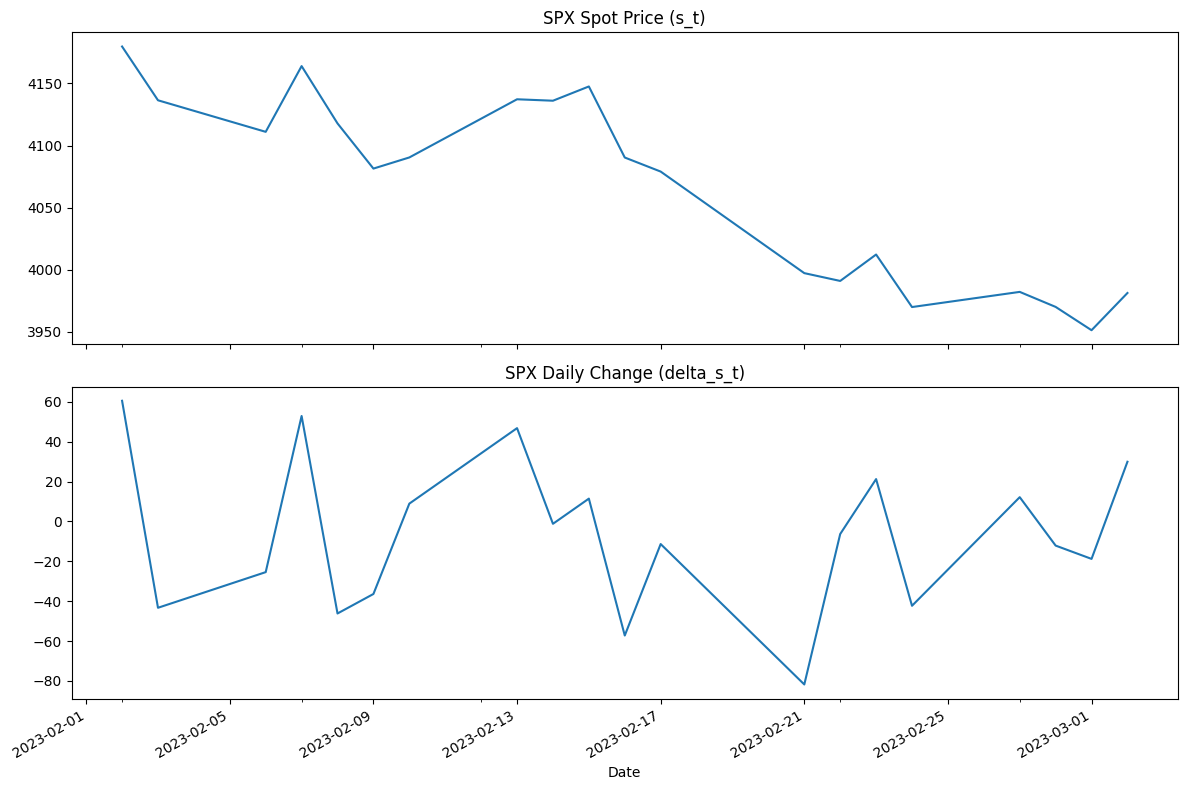

In [340]:
start = "2023-02-01"
end = "2023-03-02"

d1 = pd.Timestamp(start).strftime('%Y%m%d')
d2 = pd.Timestamp(end).strftime('%Y%m%d')

url =  f"https://stooq.com/q/d/l/?s=^spx&d1={d1}&d2={d2}&i=d"
df_spx = pd.read_csv(url, parse_dates=['Date']).sort_values('Date')

df_spx = df_spx.set_index('Date')['Close']

# rename close to s_t
df_spx = df_spx.rename("s_t")

tot_obs = len(df_spx)

# calculate delta_s_t
delta_s_t = df_spx.diff()

# add to df_spx
df_spx = df_spx.to_frame()
df_spx['delta_s_t'] = delta_s_t
df_spx = df_spx.dropna()

matched_obs = len(df_spx)

print(f"Total SPX observations: {tot_obs}")
print(f"Matched SPX observations: {matched_obs}")
print(f"Percentage of matched observations: {matched_obs / tot_obs * 100:.2f}%")

print(df_spx["s_t"].describe())
print(df_spx["delta_s_t"].describe())

# plot s_t and delta_s_t
fig, ax = plt.subplots(2, 1, figsize=(12, 8),
                          sharex=True)
df_spx['s_t'].plot(ax=ax[0], title='SPX Spot Price (s_t)')
df_spx['delta_s_t'].plot(ax=ax[1], title='SPX Daily Change (delta_s_t)')
plt.tight_layout()
plt.show() 

### 4 - Baseline Black-Scholes Delta

We choose the risk-free rate $r0.045$ based on the FED interest rate of $4.5\%$ at the beginning of Februrary 2023. $q=0.0172$ is chosen based on the SPX dividend yield in February 2023.

In [341]:
r = 0.045
q = 0.0172

def bs_delta(S, K, tau, sigma, r=r, q=q):

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return np.exp(-q * tau) * stats.norm.cdf(d1)

# Merge df_period with SPX spot prices on date
df_merged = df_period.merge(df_spx[['s_t', 'delta_s_t']], left_on='date', right_index=True, how='inner')

# Time to expiry in years
df_merged['tau'] = (df_merged['exdate'] - df_merged['date']).dt.days / 365.0

# Drop rows with non-positive tau
df_merged = df_merged[df_merged['tau'] > 0]

# Compute BS delta
df_merged['delta_BS'] = bs_delta(
    S=df_merged['s_t'].values,
    K=df_merged['strike_price'].values,
    tau=df_merged['tau'].values,
    sigma=df_merged['impl_volatility'].values,
)

print("Summary statistics for delta_BS:")
print(df_merged['delta_BS'].describe())

Summary statistics for delta_BS:
count    141619.000000
mean          0.574066
std           0.353286
min           0.000139
25%           0.237504
50%           0.674357
75%           0.902992
max           0.999921
Name: delta_BS, dtype: float64


In [342]:
# Compute residuals delta V_t - delta_BS * delta_s_t
df_merged['residual'] = df_merged['delta_V'] - df_merged['delta_BS'] * df_merged['delta_s_t']
print("Summary statistics for residuals:")
print(df_merged['residual'].describe())


Summary statistics for residuals:
count    141619.000000
mean         -1.540135
std           9.909772
min        -175.973043
25%          -3.511498
50%          -1.281264
75%           0.077221
max          96.416275
Name: residual, dtype: float64


### 5 - SABR Calibration

In [343]:
# SABR definition

def sabr_vol_atm(tau, alpha, rho, nu):
    """SABR at-the-money implied volatility using Hagan's formula."""
    correction = (rho * nu * alpha / 4 + (2 - 3 * rho**2) * nu**2 / 24) * tau
    return alpha * (1 + correction)

def sabr_vol(F, K, tau, alpha, rho, nu, atm_tol=1e-6):
    """Calculates SABR implied volatility using Hagan's formula."""
    log_fk = np.log(F / K)
    if np.abs(log_fk) < atm_tol:
        return sabr_vol_atm(tau, alpha, rho, nu)
    
    z     = (nu / alpha) * log_fk
    x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
    correction = (rho * nu * alpha / 4 + (2 - 3 * rho**2) * nu**2 / 24) * tau
    return alpha * (z / x_z) * (1 + correction)

def sabr_wrapper(F, strikes, tau, alpha, rho, nu):
    """Wraps sabr_vol to handle vectorized strikes."""
    return np.array([sabr_vol(F, K, tau, alpha, rho, nu) for K in strikes])

# SABR calibration

def cal_sabr(F, tau, strikes, market_vols, alpha0=0.3, rho0=-0.5, nu0=0.5):
    """Calibrate SABR parameters to market implied volatilities."""
    strikes = np.asarray(strikes)
    market_vols = np.asarray(market_vols)

    def objective(params):
        alpha, rho, nu = params
        fitted = sabr_wrapper(F, strikes, tau, alpha, rho, nu)
        return np.sum((fitted - market_vols)**2)
    
    bounds = [(1e-4, None), (-0.999, 0.999), (1e-4, None)]
    x0 = [alpha0, rho0, nu0]

    result = optimize.minimize(objective, x0, bounds=bounds, options={'disp': False})

    alpha_hat, rho_hat, nu_hat = result.x
    fitted_vols = sabr_wrapper(F, strikes, tau, alpha_hat, rho_hat, nu_hat)
    rmse = np.sqrt(np.mean((fitted_vols - market_vols)**2))
    
    ret_dict = {"alpha": alpha_hat, 
                "rho": rho_hat, 
                "nu": nu_hat, 
                "rmse": rmse, 
                "success": result.success, 
                "message": result.message}
    return ret_dict

def calibrate_group(group):
    """Calibrate SABR parameters for a given date and expiration group."""
    F   = group['s_t'].iloc[0]  # spot as forward proxy
    tau = group['tau'].iloc[0]

    # filter out options with unreliable implied vols
    group = group[group['impl_volatility'] < 1.5]

    if len(group) < 3:
        return pd.Series({'alpha': np.nan, 'rho': np.nan, 'nu': np.nan,
                          'rmse': np.nan, 'success': False,
                          'message': 'too few strikes after IV filter',
                          'n_strikes': 0, 'tau': tau})

    strikes     = group['strike_price'].values
    market_vols = group['impl_volatility'].values

    result = cal_sabr(F, tau, strikes, market_vols)
    result["n_strikes"] = len(strikes)
    result["tau"] = tau
    return pd.Series(result)


In [344]:
# retain only groups with at least 5 strikes for calibration
df_calib = df_merged.groupby(['date', 'exdate']).filter(lambda x: len(x) >= 5)
sabr_params = (df_calib.groupby(['date', 'exdate']).apply(calibrate_group).reset_index())

/var/folders/q8/mmx_nhwx00z606m1s1w6jzwc0000gn/T/ipykernel_35407/3690300060.py:38: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  result = optimize.minimize(objective, x0, bounds=bounds, options={'disp': False})
/var/folders/q8/mmx_nhwx00z606m1s1w6jzwc0000gn/T/ipykernel_35407/3690300060.py:15: RuntimeWarning: invalid value encountered in log
  x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))


In [345]:
print(sabr_params.head(20))
print(f"\nCalibration failures: {(~sabr_params['success']).sum()}")
print(f"Median RMSE: {sabr_params['rmse'].median():.6f}")

         date     exdate     alpha       rho         nu      rmse  success  \
0  2023-02-02 2023-02-03  0.207655 -0.140290  17.870875  0.067020     True   
1  2023-02-02 2023-02-06  0.145050  0.229697   6.866513  0.025606     True   
2  2023-02-02 2023-02-07  0.154201  0.248532   5.450789  0.024383     True   
3  2023-02-02 2023-02-08  0.162907  0.286358   3.945259  0.016564     True   
4  2023-02-02 2023-02-09  0.161223  0.211051   4.107846  0.018965     True   
5  2023-02-02 2023-02-10  0.149548  0.068818   4.704797  0.020313     True   
6  2023-02-02 2023-02-13  0.146318  0.191687   3.032399  0.013004     True   
7  2023-02-02 2023-02-14  0.167868  0.196315   2.759042  0.016848     True   
8  2023-02-02 2023-02-15  0.171040  0.225282   1.916592  0.013815     True   
9  2023-02-02 2023-02-16  0.173065  0.074402   2.239491  0.013118     True   
10 2023-02-02 2023-02-17  0.133157 -0.165558   4.387348  0.032049     True   
11 2023-02-02 2023-02-21  0.156279  0.032013   1.985911  0.01145

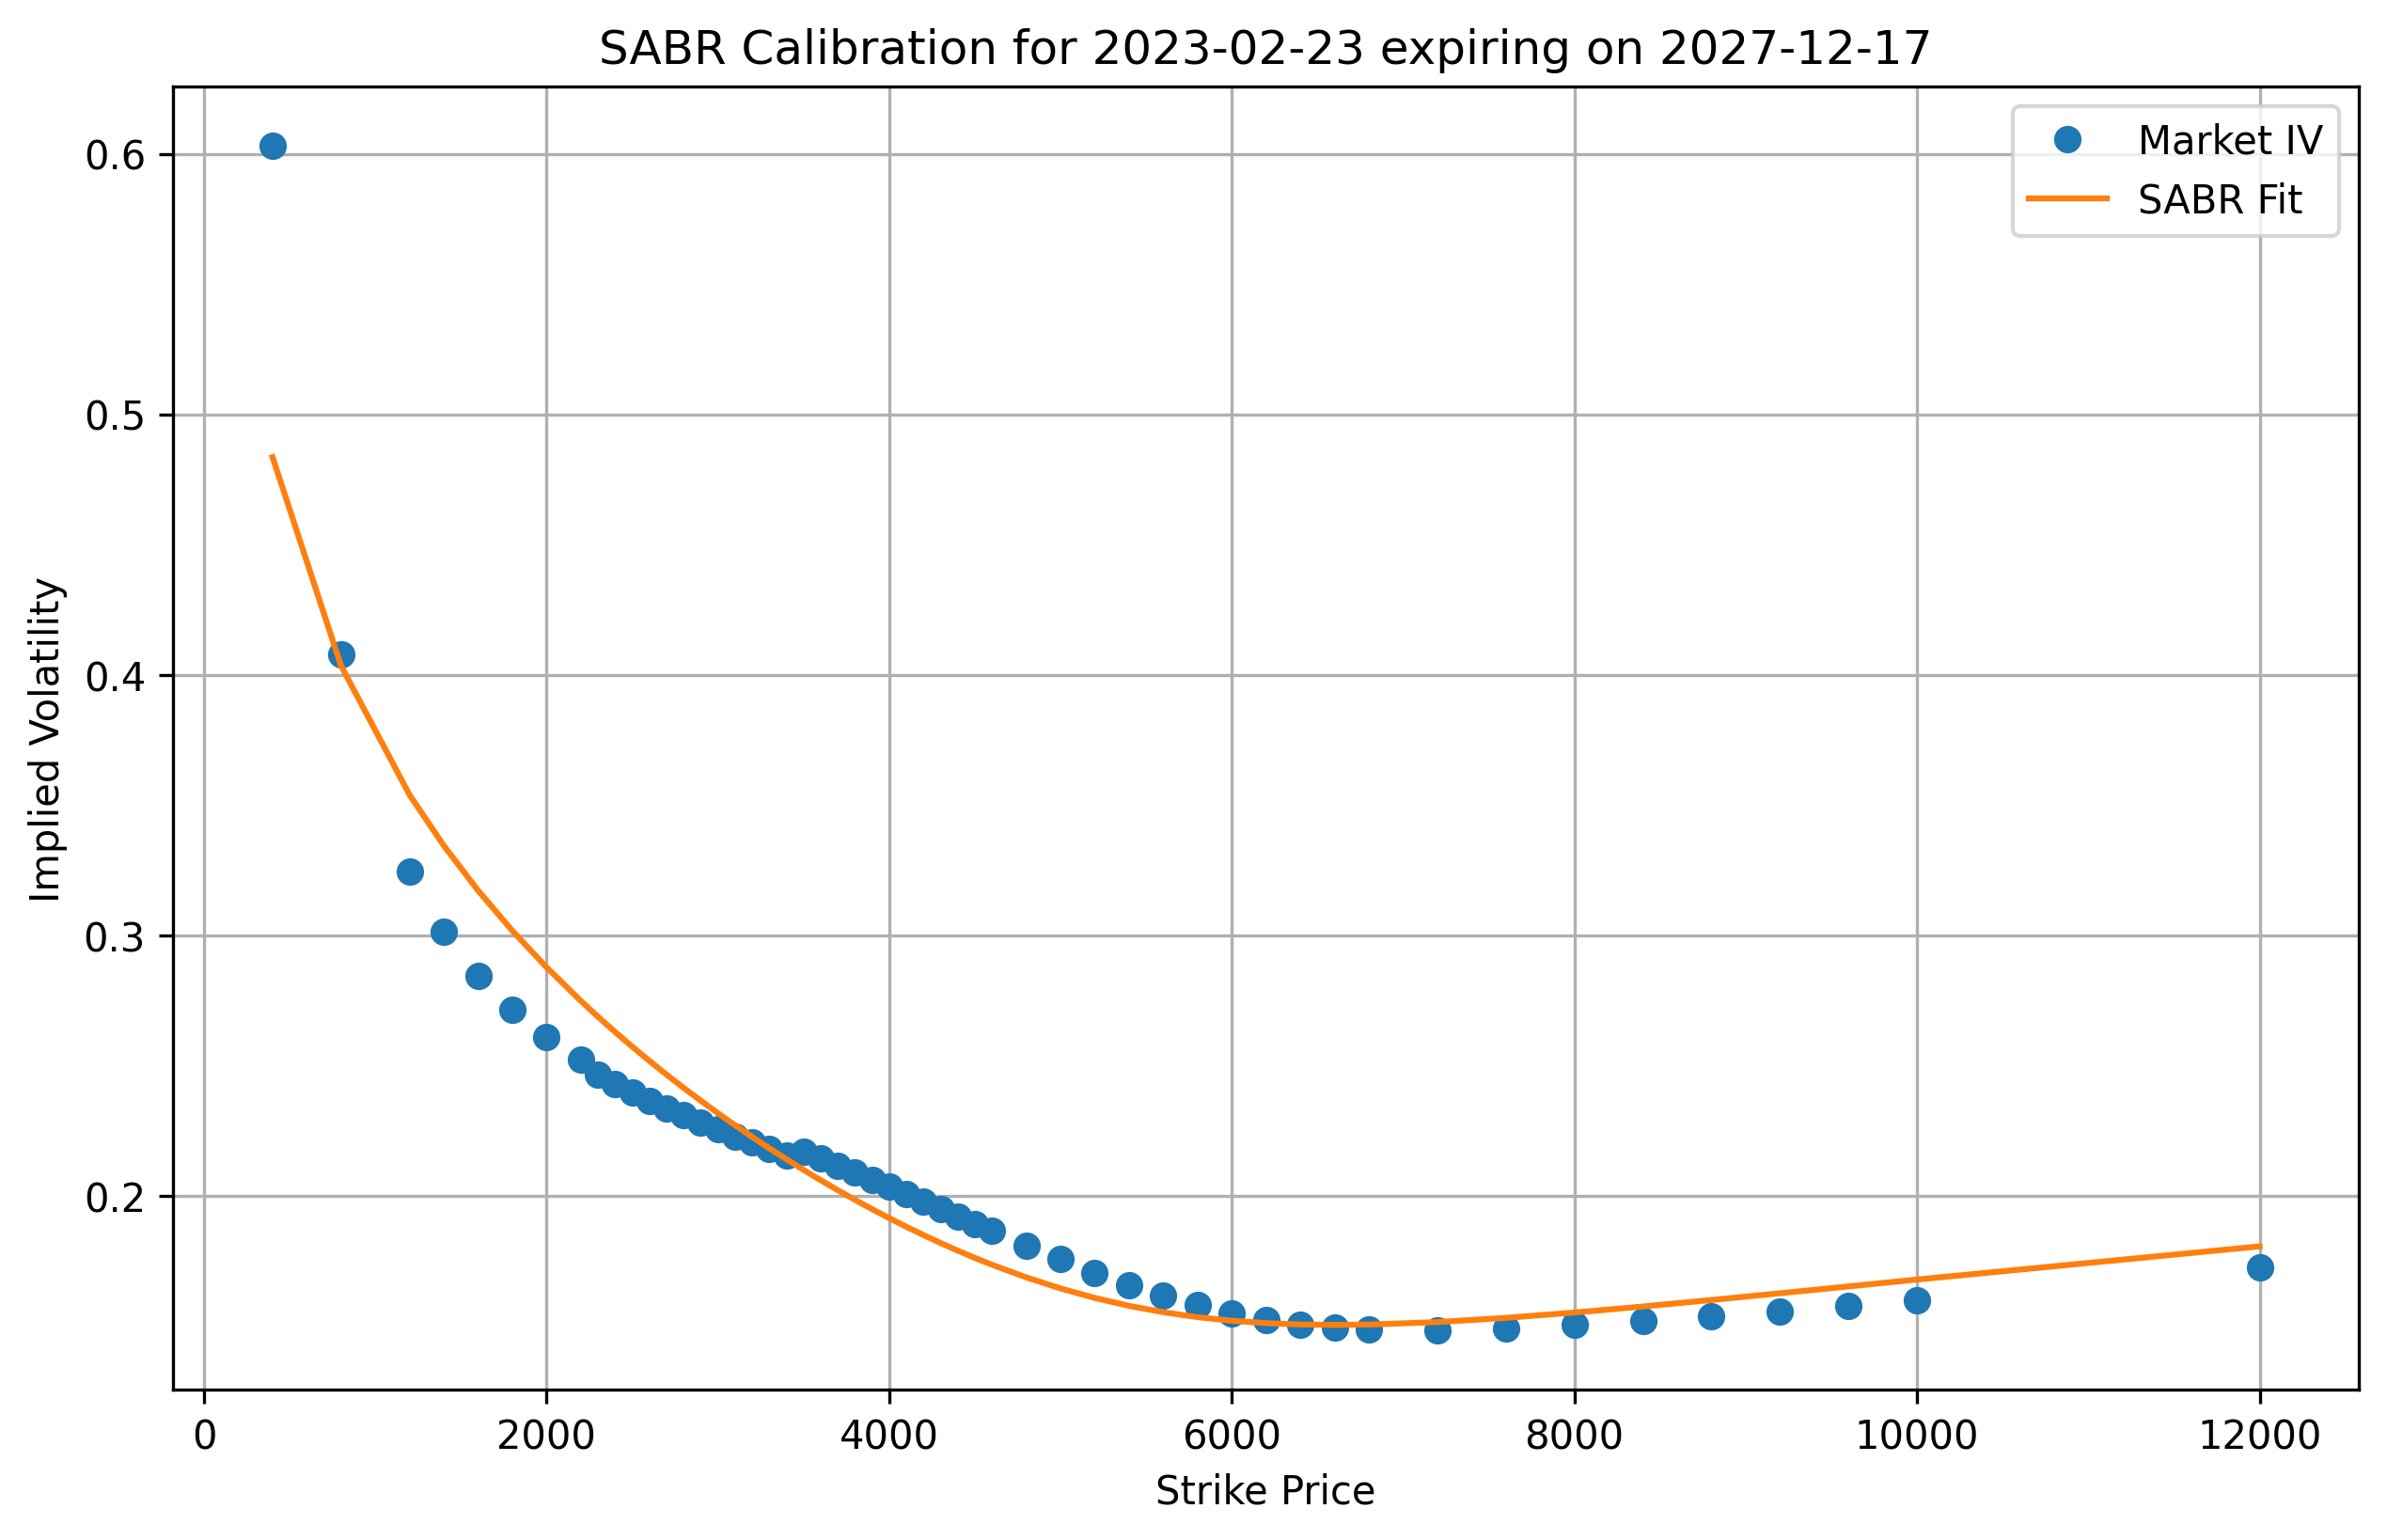

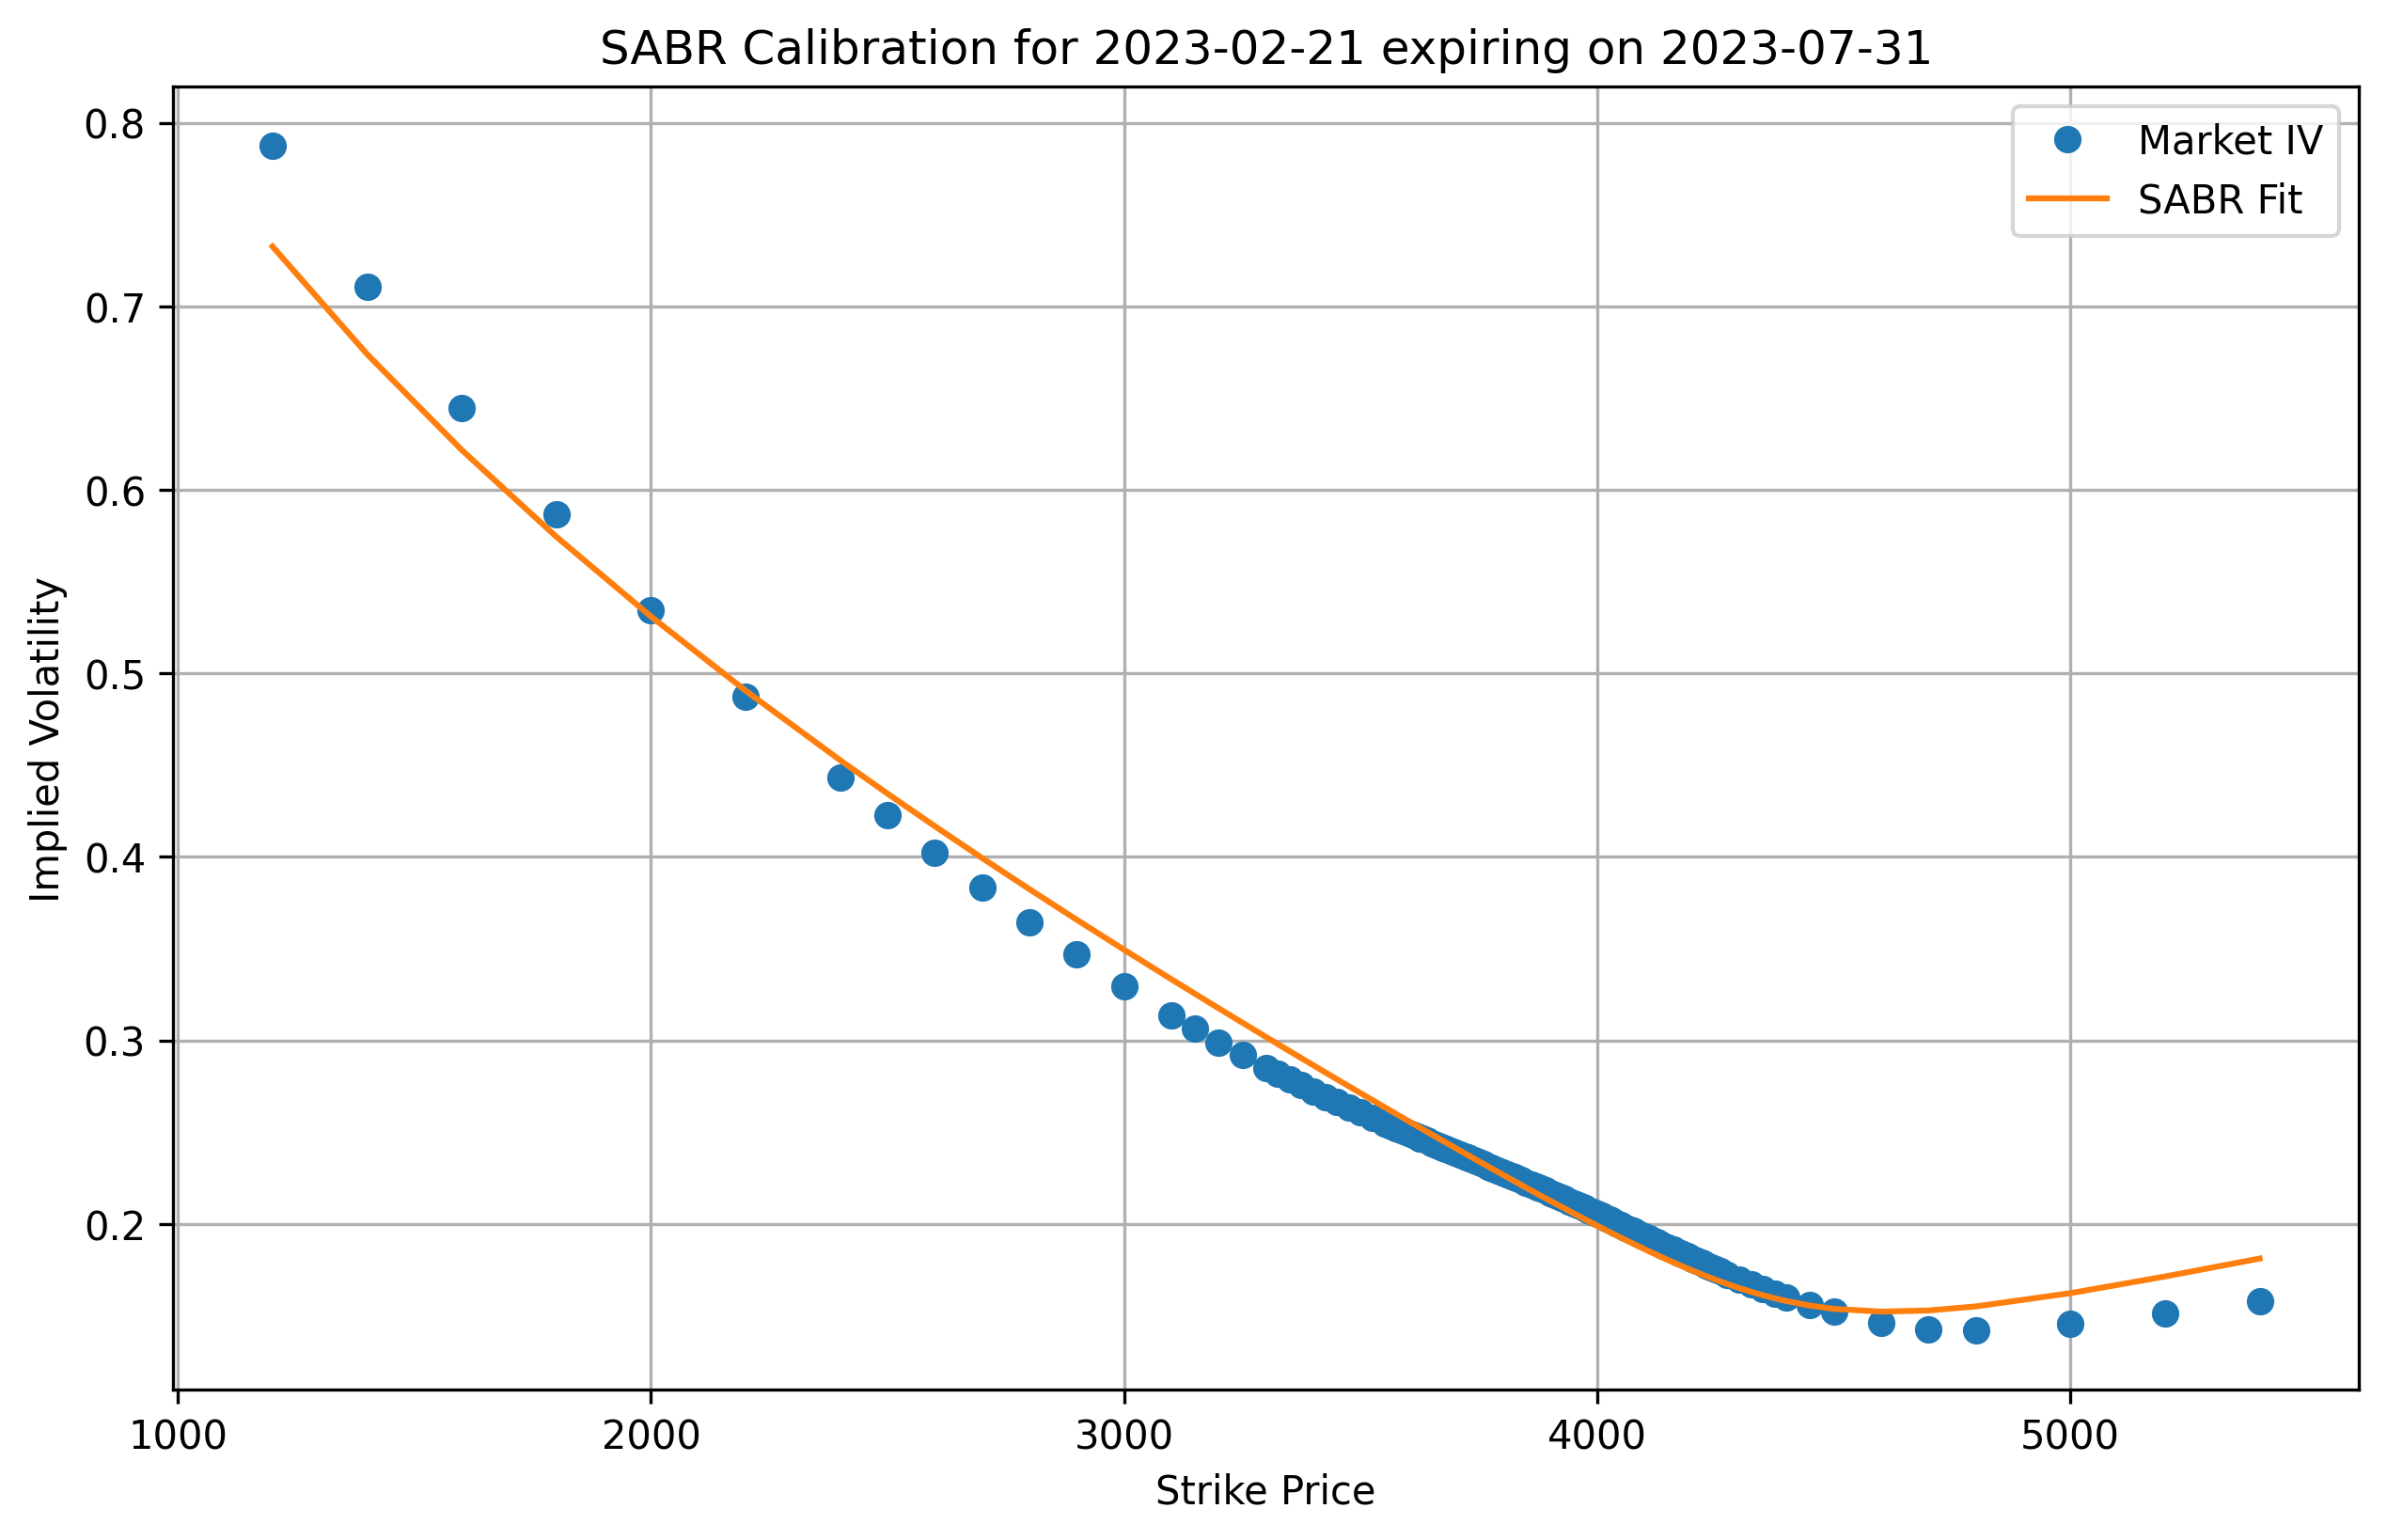

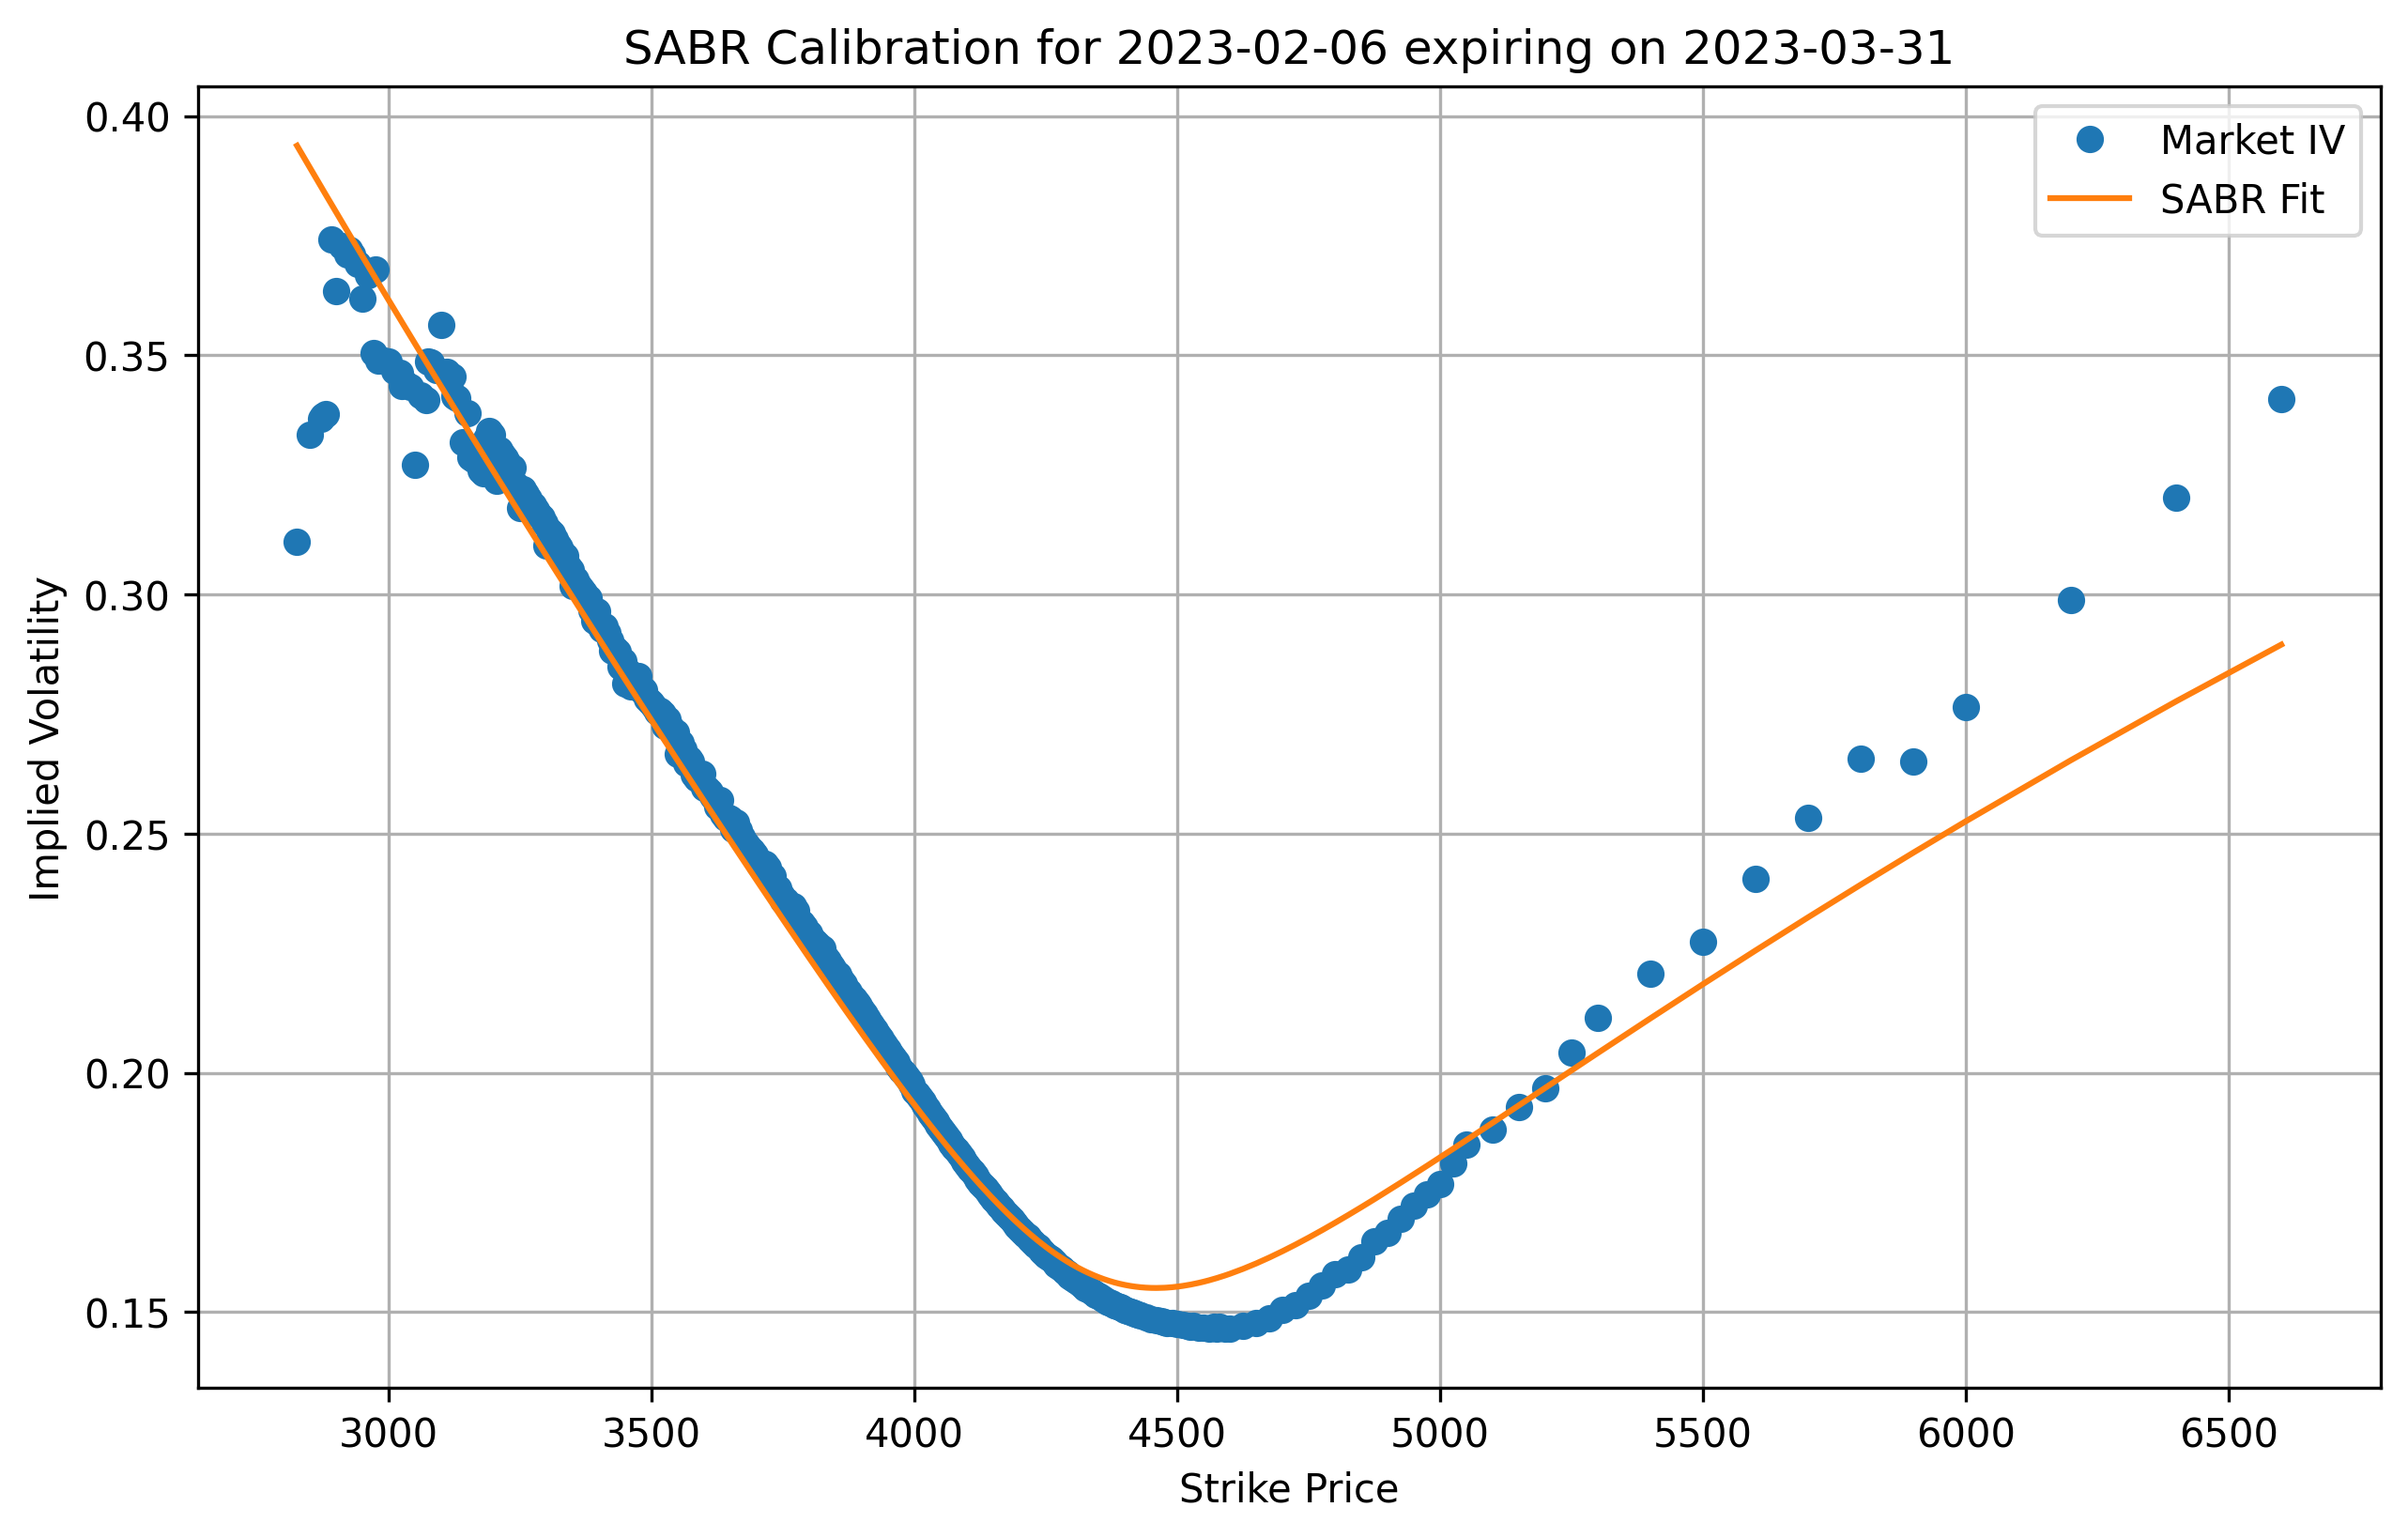

In [346]:
# select a few successful calibrations for plotting
sample_groups = sabr_params[sabr_params['success']].sample(3, random_state=42)    

# plot smile for these groups
for _, row in sample_groups.iterrows():
    date = row['date']
    exdate = row['exdate']
    alpha, rho, nu = row['alpha'], row['rho'], row['nu']
    
    group_data = df_merged[(df_merged['date'] == date) & (df_merged['exdate'] == exdate)]
    group_data = group_data.sort_values('strike_price')  # sort by strike
    strikes = group_data['strike_price'].values
    market_vols = group_data['impl_volatility'].values
    F = group_data['s_t'].iloc[0]
    tau = group_data['tau'].iloc[0]
    
    fitted_vols = sabr_wrapper(F, strikes, tau, alpha, rho, nu)
    
    plt.figure(figsize=(10, 6), dpi=300)
    plt.plot(strikes, market_vols, 'o', label='Market IV')
    plt.plot(strikes, fitted_vols, '-', label='SABR Fit')
    plt.title(f"SABR Calibration for {date.date()} expiring on {exdate.date()}")
    plt.xlabel("Strike Price")
    plt.ylabel("Implied Volatility")
    plt.legend()
    plt.grid()
    plt.show()


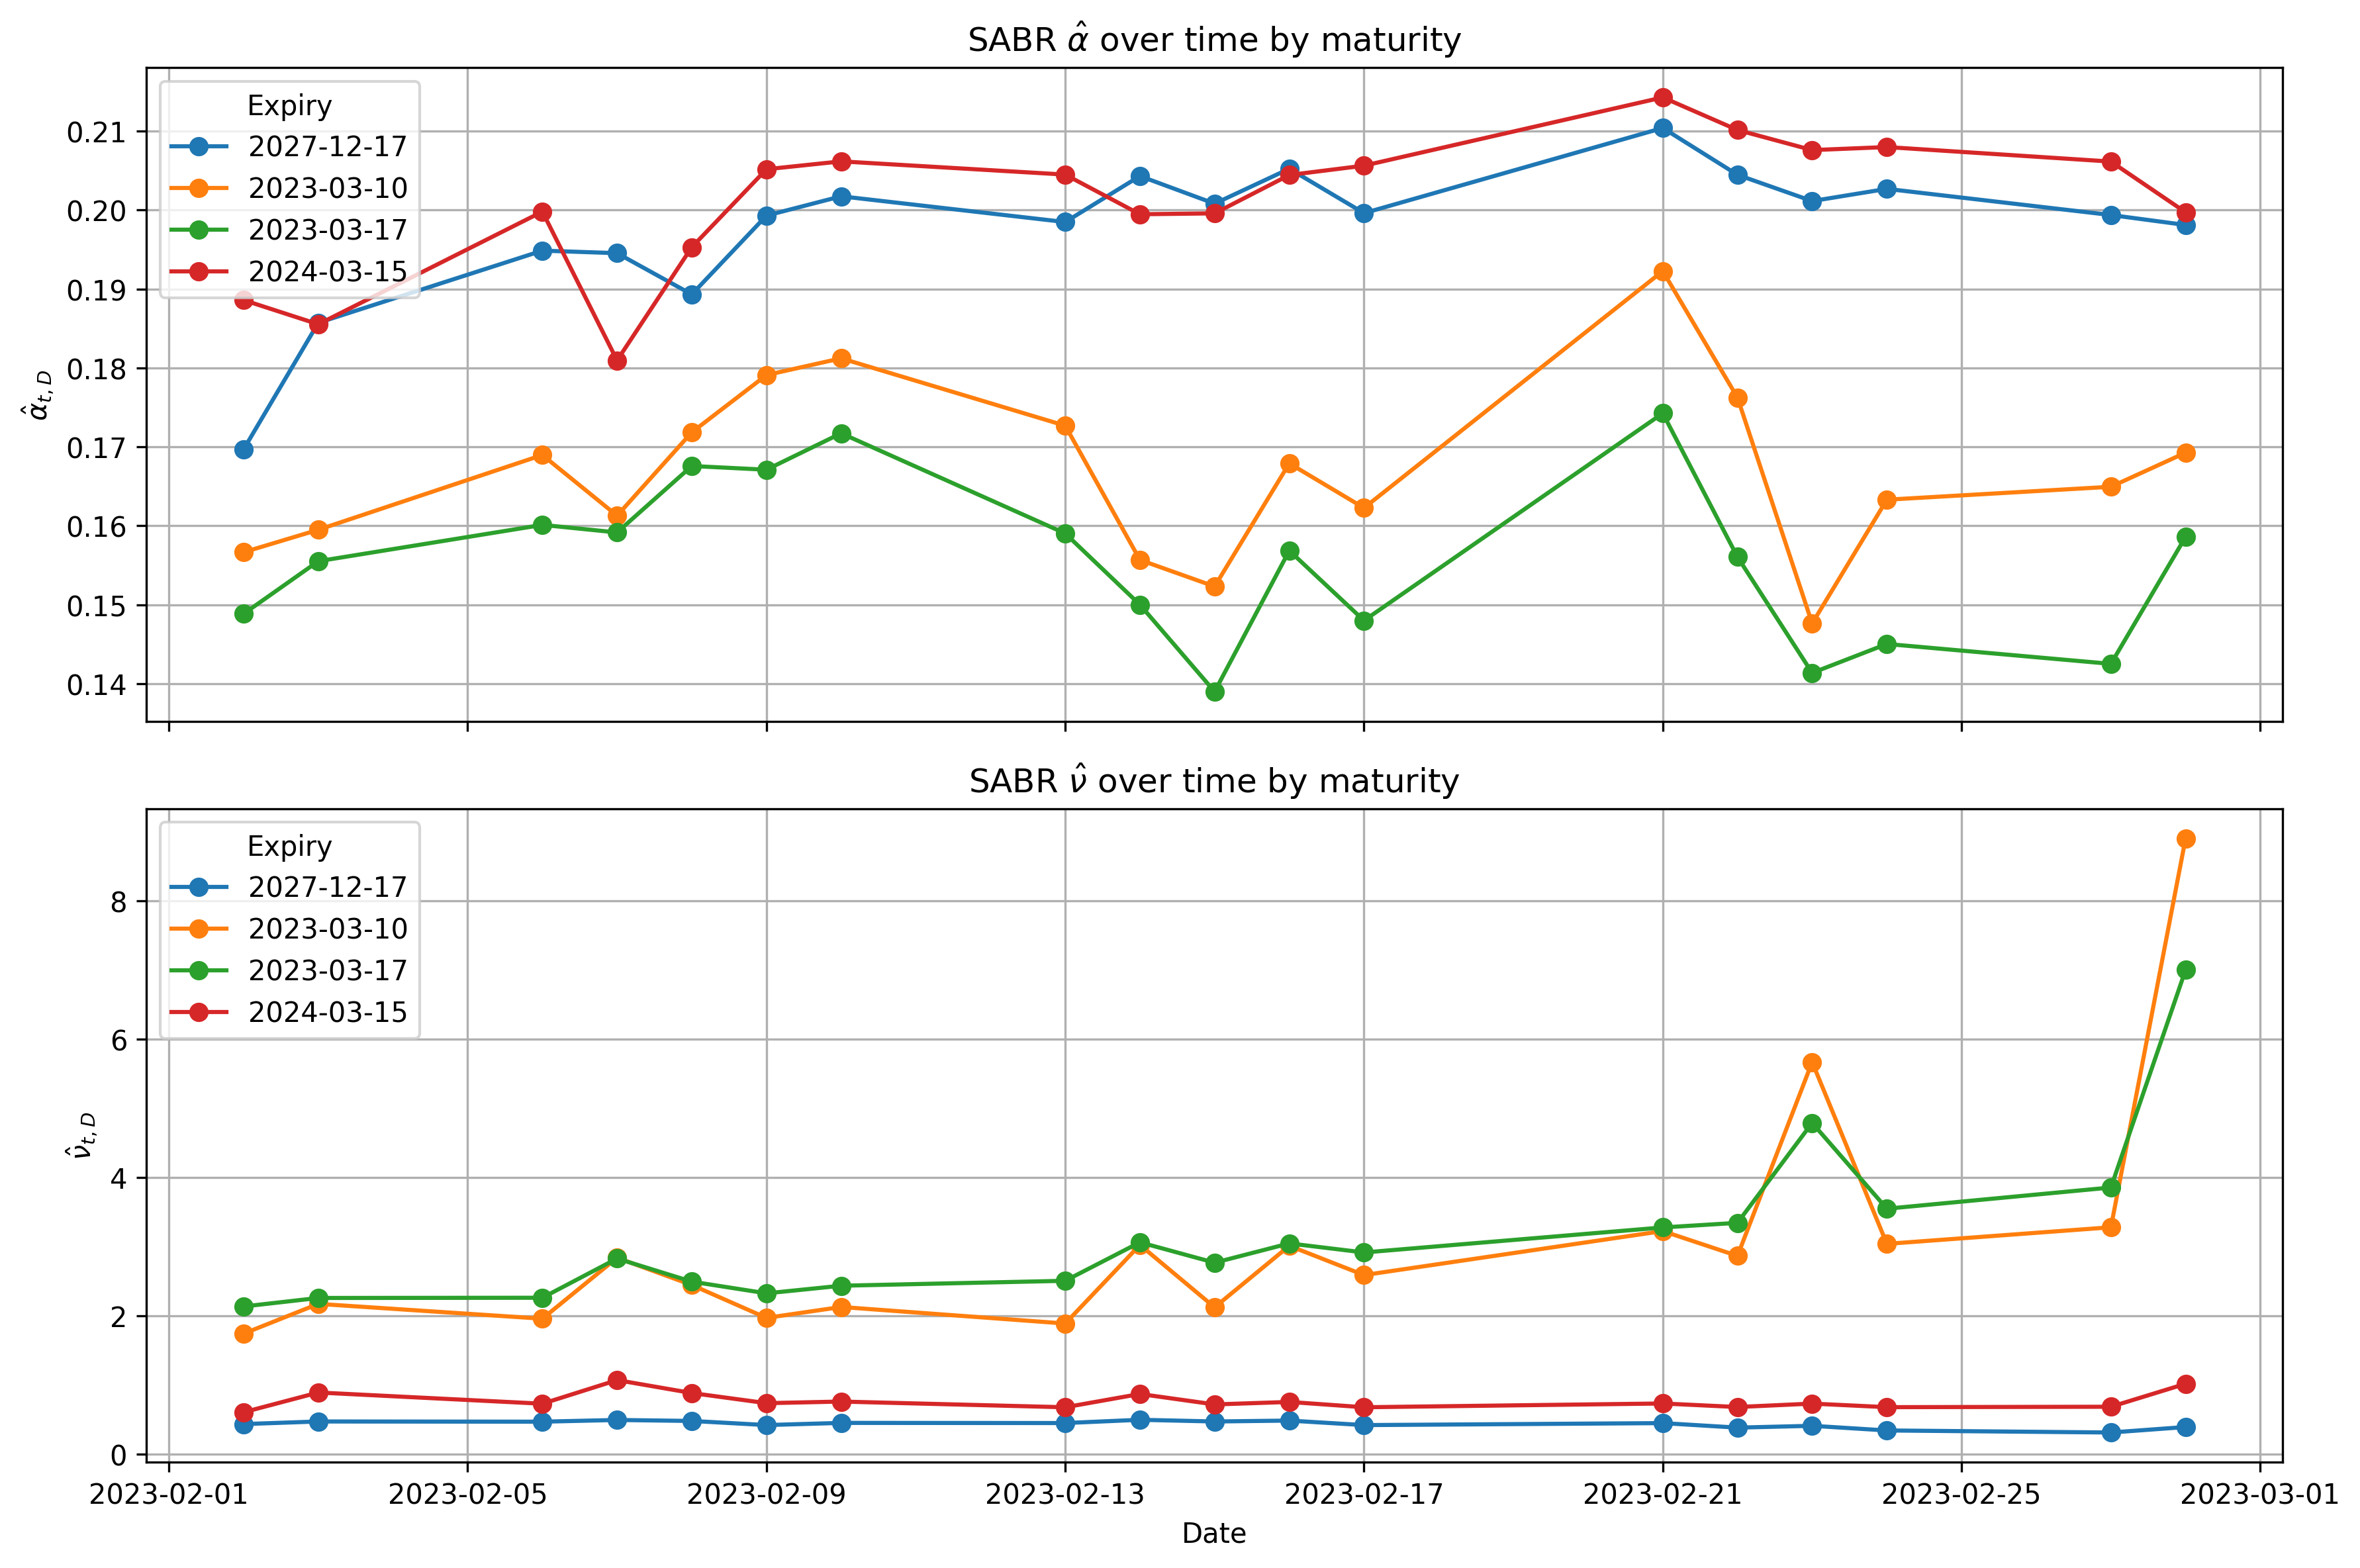

In [347]:
# pick expiries with the most observations across dates
top_expiries = (sabr_params.groupby('exdate')['date']
                .nunique()
                .sort_values(ascending=False)
                .head(4).index)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, dpi=300)

for exdate in top_expiries:
    slice_ = sabr_params[sabr_params['exdate'] == exdate].sort_values('date')
    label = exdate.date()
    axes[0].plot(slice_['date'], slice_['alpha'], marker='o', label=label)
    axes[1].plot(slice_['date'], slice_['nu'],   marker='o', label=label)
    axes[0].grid(True)
    axes[1].grid(True)

axes[0].set_ylabel(r'$\hat{\alpha}_{t,D}$')
axes[1].set_ylabel(r'$\hat{\nu}_{t,D}$')
axes[1].set_xlabel('Date')
axes[0].set_title(r'SABR $\hat{\alpha}$ over time by maturity')
axes[1].set_title(r'SABR $\hat{\nu}$ over time by maturity')
axes[0].legend(title='Expiry')
axes[1].legend(title='Expiry')
plt.tight_layout()
plt.show()

Note that for near-expiry slices (orange, green), large $\alpha$ and $\nu$ values are chosen by SABR to compensate for the sharp volatility smile with near vertical skew.

In [348]:
# calibration error analysis on (t, D, K) grid

def compute_fitted_vols(df, sabr_params):
    """Merge SABR fitted vols back onto the (t, D, K) grid."""
    records = []
    for _, row in sabr_params[sabr_params['success']].iterrows():
        group = df[(df['date'] == row['date']) & (df['exdate'] == row['exdate'])]
        group = group[group['impl_volatility'] < 1.5]  # match calibration filter
        if len(group) == 0:
            continue
        F   = group['s_t'].iloc[0]  # spot as forward proxy, matching calibrate_group
        tau = group['tau'].iloc[0]
        fitted = sabr_wrapper(F, group['strike_price'].values, tau,
                              row['alpha'], row['rho'], row['nu'])
        tmp = group[['date', 'exdate', 'strike_price', 'impl_volatility']].copy()
        tmp['fitted_vol'] = fitted
        records.append(tmp)
    return pd.concat(records, ignore_index=True)

df_errors = compute_fitted_vols(df_merged, sabr_params)
df_errors['error']     = df_errors['fitted_vol'] - df_errors['impl_volatility']
df_errors['abs_error'] = df_errors['error'].abs()
df_errors['sq_error']  = df_errors['error'] ** 2

# Overall metrics
mae  = df_errors['abs_error'].mean()
mse  = df_errors['sq_error'].mean()
rmse = np.sqrt(mse)
print(f"Overall  MAE:  {mae:.6f}")
print(f"Overall  MSE:  {mse:.6f}")
print(f"Overall  RMSE: {rmse:.6f}")

# Per-slice (t, D) metrics
slice_errors = df_errors.groupby(['date', 'exdate']).agg(
    MAE  = ('abs_error', 'mean'),
    MSE  = ('sq_error',  'mean'),
    RMSE = ('sq_error',  lambda x: np.sqrt(x.mean())),
    n_strikes = ('strike_price', 'count')
).reset_index()

print("\nPer-slice error summary:")
print(slice_errors.describe())

print(slice_errors.sort_values('RMSE', ascending=False).head(10)[['date', 'exdate', 'RMSE', 'n_strikes']])


Overall  MAE:  0.013163
Overall  MSE:  0.000525
Overall  RMSE: 0.022903

Per-slice error summary:
                             date                      exdate         MAE  \
count                         859                         859  859.000000   
mean   2023-02-14 16:37:26.332945  2023-09-05 02:37:34.714784    0.012773   
min           2023-02-02 00:00:00         2023-02-03 00:00:00    0.001103   
25%           2023-02-08 00:00:00         2023-03-06 00:00:00    0.005229   
50%           2023-02-14 00:00:00         2023-04-14 00:00:00    0.009119   
75%           2023-02-22 00:00:00         2023-10-20 00:00:00    0.016879   
max           2023-02-28 00:00:00         2027-12-17 00:00:00    0.139833   
std                           NaN                         NaN    0.011238   

              MSE        RMSE   n_strikes  
count  859.000000  859.000000  859.000000  
mean     0.000522    0.017651  164.235157  
min      0.000002    0.001466   34.000000  
25%      0.000065    0.008075   

### 6 - SABR delta, Bartlett delta

In [349]:
# Black formula greeks (forward form)

def black_d1(F, K, tau, sigma):
    return (np.log(F / K) + 0.5 * sigma**2 * tau) / (sigma * np.sqrt(tau))

def black_price(F, K, tau, sigma, r=r):
    d1 = black_d1(F, K, tau, sigma)
    d2 = d1 - sigma * np.sqrt(tau)
    return np.exp(-r * tau) * (F * stats.norm.cdf(d1) - K * stats.norm.cdf(d2))

def black_dB_dF(F, K, tau, sigma, r=r):
    d1 = black_d1(F, K, tau, sigma)
    return np.exp(-r * tau) * stats.norm.cdf(d1)

def black_dB_dsigma(F, K, tau, sigma, r=r):
    d1 = black_d1(F, K, tau, sigma)
    return np.exp(-r * tau) * F * np.sqrt(tau) * stats.norm.pdf(d1)

def black_delta_S(F, K, tau, sigma, r=r, q=q):
    return np.exp((r - q) * tau) * black_dB_dF(F, K, tau, sigma, r)

def black_vega_S(F, K, tau, sigma, r=r, q=q):
    return np.exp((r - q) * tau) * black_dB_dsigma(F, K, tau, sigma, r)

# SABR delta

def dsigma_dF(F, K, tau, alpha, rho, nu, h_rel=1e-4):
    h = h_rel * F
    return (sabr_vol(F + h, K, tau, alpha, rho, nu) -
            sabr_vol(F - h, K, tau, alpha, rho, nu)) / (2 * h)

def dsigma_dalpha(F, K, tau, alpha, rho, nu, h_rel=1e-4):
    h = h_rel * alpha
    return (sabr_vol(F, K, tau, alpha + h, rho, nu) -
            sabr_vol(F, K, tau, alpha - h, rho, nu)) / (2 * h)

def sabr_delta(F, K, tau, sigma_imp, alpha, rho, nu, r=r, q=q):
    dB_dF = black_dB_dF(F, K, tau, sigma_imp, r)
    dB_ds = black_dB_dsigma(F, K, tau, sigma_imp, r)
    ds_dF = dsigma_dF(F, K, tau, alpha, rho, nu)
    return np.exp((r - q) * tau) * (dB_dF + dB_ds * ds_dF)

# Bartlett delta

def bartlett_delta(F, K, tau, sigma_imp, alpha, rho, nu, r=r, q=q):
    dB_dF   = black_dB_dF(F, K, tau, sigma_imp, r)
    dB_ds   = black_dB_dsigma(F, K, tau, sigma_imp, r)
    ds_dF   = dsigma_dF(F, K, tau, alpha, rho, nu)
    ds_da   = dsigma_dalpha(F, K, tau, alpha, rho, nu)
    skew_adj = ds_dF + ds_da * (rho * nu / F)   # β=1 so F^β = F
    return np.exp((r - q) * tau) * (dB_dF + dB_ds * skew_adj)

#### Role of $\rho$ in skew adjustment
In the Bartlett correction, we add $\frac{\partial \sigma}{\partial \alpha} \rho \nu / F$ to the $\partial \sigma / \partial F$ term. When $F$ moves by $dF$, the $\alpha$ of the SABR process shifts due to the correlation $\rho$ and the extra Bartlett term accouts for the impact of this shifts on the implied volatility,.



Slice: 2023-02-03 → 2023-05-31, τ=0.321, RMSE=0.00147
α=0.1740, ρ=-0.6956, ν=1.3941


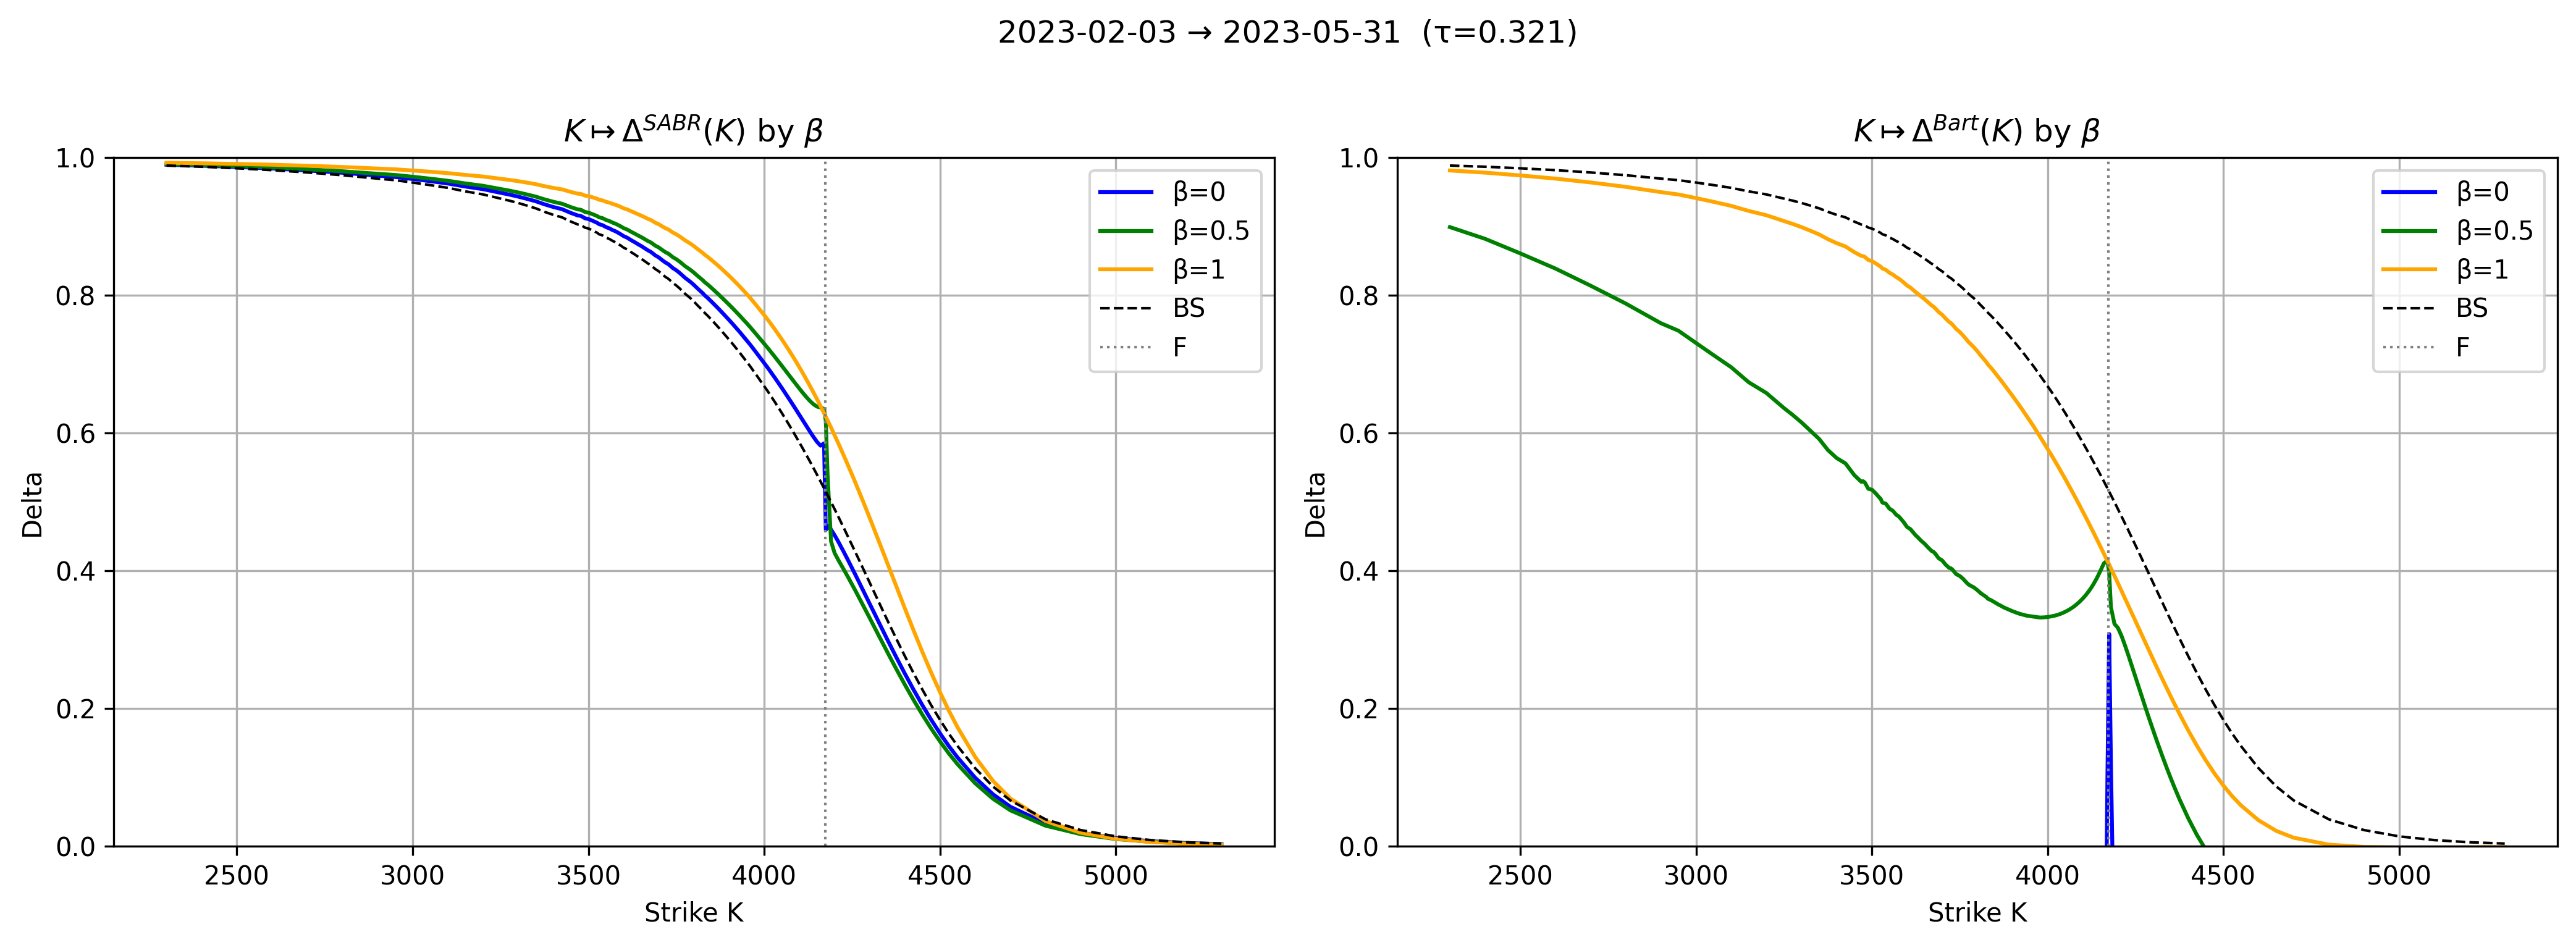

In [350]:
# General-β SABR vol and deltas for the concept plot

def sabr_vol_beta(F, K, tau, alpha, rho, nu, beta, atm_tol=1e-6):
    """Full Hagan SABR formula with general β."""
    log_fk = np.log(F / K)
    FK_mid = (F * K) ** ((1 - beta) / 2)

    # correction term (same structure for all β)
    correction = (
        ((1 - beta)**2 * alpha**2) / (24 * (F * K)**(1 - beta))
        + rho * beta * nu * alpha / (4 * FK_mid)
        + (2 - 3 * rho**2) * nu**2 / 24
    ) * tau

    # ATM case
    vol_atm = (alpha / F**(1 - beta)) * (1 + correction)

    # non-ATM case
    log_expansion = 1 + ((1-beta)**2 / 24) * log_fk**2 + ((1-beta)**4 / 1920) * log_fk**4
    z   = (nu / alpha) * FK_mid * log_fk
    x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = np.where(np.abs(x_z) > 1e-10, z / x_z, 1.0)
    vol_non_atm = (alpha / (FK_mid * log_expansion)) * ratio * (1 + correction)

    return np.where(np.abs(log_fk) < atm_tol, vol_atm, vol_non_atm)

def dsigma_dF_beta(F, K, tau, alpha, rho, nu, beta, h_rel=1e-4):
    h = h_rel * F
    return (sabr_vol_beta(F + h, K, tau, alpha, rho, nu, beta) -
            sabr_vol_beta(F - h, K, tau, alpha, rho, nu, beta)) / (2 * h)

def dsigma_dalpha_beta(F, K, tau, alpha, rho, nu, beta, h_rel=1e-4):
    h = h_rel * alpha
    return (sabr_vol_beta(F, K, tau, alpha + h, rho, nu, beta) -
            sabr_vol_beta(F, K, tau, alpha - h, rho, nu, beta)) / (2 * h)

def sabr_delta_beta(F, K, tau, sigma_imp, alpha, rho, nu, beta, r=r, q=q):
    dB_dF = np.exp(-r * tau) * stats.norm.cdf(black_d1(F, K, tau, sigma_imp))
    dB_ds = np.exp(-r * tau) * F * np.sqrt(tau) * stats.norm.pdf(black_d1(F, K, tau, sigma_imp))
    ds_dF = dsigma_dF_beta(F, K, tau, alpha, rho, nu, beta)
    return np.exp((r - q) * tau) * (dB_dF + dB_ds * ds_dF)

def bartlett_delta_beta(F, K, tau, sigma_imp, alpha, rho, nu, beta, r=r, q=q):
    dB_dF = np.exp(-r * tau) * stats.norm.cdf(black_d1(F, K, tau, sigma_imp))
    dB_ds = np.exp(-r * tau) * F * np.sqrt(tau) * stats.norm.pdf(black_d1(F, K, tau, sigma_imp))
    ds_dF = dsigma_dF_beta(F, K, tau, alpha, rho, nu, beta)
    ds_da = dsigma_dalpha_beta(F, K, tau, alpha, rho, nu, beta)
    skew_adj = ds_dF + ds_da * (rho * nu / F**beta)
    return np.exp((r - q) * tau) * (dB_dF + dB_ds * skew_adj)

# --- Plot: fixed (t, D), vary β ---
# Pick a well-calibrated slice (good RMSE, reasonable tau)
slice_row = sabr_params[
    sabr_params['success'] & (sabr_params['rmse'] < 0.01)
].sort_values('rmse').iloc[0]

date_fix   = slice_row['date']
exdate_fix = slice_row['exdate']
alpha_fix  = slice_row['alpha']
rho_fix    = slice_row['rho']
nu_fix     = slice_row['nu']

group = df_merged[(df_merged['date'] == date_fix) & (df_merged['exdate'] == exdate_fix)]
group = group[(group['impl_volatility'] < 1.5)].sort_values('strike_price')
S_fix   = group['s_t'].iloc[0]
tau_fix = group['tau'].iloc[0]
F_fix   = S_fix * np.exp((r - q) * tau_fix)
strikes = group['strike_price'].values
sigmas  = group['impl_volatility'].values

print(f"Slice: {date_fix.date()} → {exdate_fix.date()}, τ={tau_fix:.3f}, RMSE={slice_row['rmse']:.5f}")
print(f"α={alpha_fix:.4f}, ρ={rho_fix:.4f}, ν={nu_fix:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)
colors = {0: 'blue', 0.5: 'green', 1: 'orange'}

for beta in [0, 0.5, 1]:
    d_sabr = sabr_delta_beta(F_fix, strikes, tau_fix, sigmas, alpha_fix, rho_fix, nu_fix, beta)
    d_bart = bartlett_delta_beta(F_fix, strikes, tau_fix, sigmas, alpha_fix, rho_fix, nu_fix, beta)
    axes[0].plot(strikes, d_sabr, label=f'β={beta}', color=colors[beta])
    axes[1].plot(strikes, d_bart, label=f'β={beta}', color=colors[beta])

# add BS delta as reference
d_bs = bs_delta(S=S_fix, K=strikes, tau=tau_fix, sigma=sigmas)
for ax in axes:
    ax.plot(strikes, d_bs, 'k--', label='BS', linewidth=1)
    ax.axvline(F_fix, color='grey', linestyle=':', linewidth=1, label='F')
    ax.set_xlabel('Strike K')
    ax.set_ylabel('Delta')
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid()

axes[0].set_title(r'$K \mapsto \Delta^{SABR}(K)$ by $\beta$')
axes[1].set_title(r'$K \mapsto \Delta^{Bart}(K)$ by $\beta$')
plt.suptitle(f'{date_fix.date()} → {exdate_fix.date()}  (τ={tau_fix:.3f})', y=1.01)
plt.tight_layout()
plt.show()


The $\beta = 0$ Bartlett delta is numerically unstable when evaluated at parameters calibrated under $\beta = 1$ ($\frac{\rho \nu}{F^{\beta}}$) converges to $\rho \nu$ which is magnitudes larger than the term for $\beta \neq 0$.

In [351]:
# Vectorized SABR vol and greeks

def sabr_vol_vec(F, K, tau, alpha, rho, nu, atm_tol=1e-6):
    """Fully vectorized SABR vol — all inputs can be numpy arrays."""
    log_fk = np.log(F / K)
    correction = (rho * nu * alpha / 4 + (2 - 3 * rho**2) * nu**2 / 24) * tau
    vol_atm = alpha * (1 + correction)

    z   = (nu / alpha) * log_fk
    x_z = np.log((np.sqrt(1 - 2*rho*z + z**2) + z - rho) / (1 - rho))
    with np.errstate(invalid='ignore', divide='ignore'):
        ratio = np.where(np.abs(x_z) > 1e-10, z / x_z, 1.0)
    vol_non_atm = alpha * ratio * (1 + correction)

    return np.where(np.abs(log_fk) < atm_tol, vol_atm, vol_non_atm)

def dsigma_dF_vec(F, K, tau, alpha, rho, nu, h_rel=1e-4):
    h = h_rel * F
    return (sabr_vol_vec(F + h, K, tau, alpha, rho, nu) -
            sabr_vol_vec(F - h, K, tau, alpha, rho, nu)) / (2 * h)

def dsigma_dalpha_vec(F, K, tau, alpha, rho, nu, h_rel=1e-4):
    h = h_rel * alpha
    return (sabr_vol_vec(F, K, tau, alpha + h, rho, nu) -
            sabr_vol_vec(F, K, tau, alpha - h, rho, nu)) / (2 * h)

# Merge SABR params onto df_merged by (date, exdate)
df_deltas = df_merged.merge(
    sabr_params[sabr_params['success']][['date', 'exdate', 'alpha', 'rho', 'nu']],
    on=['date', 'exdate'],
    how='inner'
)

# Extract arrays
F     = df_deltas['s_t'].values
K     = df_deltas['strike_price'].values
tau   = df_deltas['tau'].values
sigma = df_deltas['impl_volatility'].values
alpha = df_deltas['alpha'].values
rho   = df_deltas['rho'].values
nu    = df_deltas['nu'].values

# Vectorized greeks
dB_dF  = np.exp(-r * tau) * stats.norm.cdf(black_d1(F, K, tau, sigma))
dB_ds  = np.exp(-r * tau) * F * np.sqrt(tau) * stats.norm.pdf(black_d1(F, K, tau, sigma))
ds_dF  = dsigma_dF_vec(F, K, tau, alpha, rho, nu)
ds_da  = dsigma_dalpha_vec(F, K, tau, alpha, rho, nu)
scale  = np.exp((r - q) * tau)

df_deltas['delta_SABR']     = scale * (dB_dF + dB_ds * ds_dF)
df_deltas['delta_Bartlett'] = scale * (dB_dF + dB_ds * (ds_dF + ds_da * (rho * nu / F)))

print("Total rows before filtering deltas: ", len(df_deltas))
# drop BS deltas <= 0.05 and >= 0.95
df_deltas = df_deltas[(df_deltas['delta_BS'] > 0.05) & (df_deltas['delta_BS'] < 0.95)]
print("Total rows after filtering BS deltas: ", len(df_deltas))
# drop D_t <= 14 days
df_deltas = df_deltas[df_deltas['tau'] > 14/365]
print("Total rows after filtering short-dated options: ", len(df_deltas))
# drop undef calibrated slices (alpha or nu is NaN)
df_deltas = df_deltas.dropna(subset=['alpha', 'nu'])
print("Total rows after dropping uncalibrated slices: ", len(df_deltas), "\n")

# Compare distributions
print(df_deltas[['delta_BS', 'delta_SABR', 'delta_Bartlett']].describe())
print(f"\nMean |Δ_SABR - Δ_BS|:   {(df_deltas['delta_SABR'] - df_deltas['delta_BS']).abs().mean():.6f}")
print(f"Mean |Δ_Bart - Δ_BS|:   {(df_deltas['delta_Bartlett'] - df_deltas['delta_BS']).abs().mean():.6f}")
print(f"Mean |Δ_Bart - Δ_SABR|: {(df_deltas['delta_Bartlett'] - df_deltas['delta_SABR']).abs().mean():.6f}")


Total rows before filtering deltas:  141619
Total rows after filtering BS deltas:  98412
Total rows after filtering short-dated options:  86568
Total rows after dropping uncalibrated slices:  86568 

           delta_BS    delta_SABR  delta_Bartlett
count  86568.000000  86568.000000    86568.000000
mean       0.611904      0.657669        0.510035
std        0.267652      0.287458        0.292490
min        0.050006      0.010830       -0.044517
25%        0.401259      0.446530        0.252742
50%        0.676916      0.756817        0.560440
75%        0.850072      0.906462        0.774688
max        0.949998      0.990593        0.958007

Mean |Δ_SABR - Δ_BS|:   0.051234
Mean |Δ_Bart - Δ_BS|:   0.101920
Mean |Δ_Bart - Δ_SABR|: 0.147638


In [352]:
# create 9 moneyness bins based on delta_BS (between 0.05 and 0.95)
bins = [0.05, 0.1, 0.3, 0.45, 0.55, 0.7, 0.9, 0.95]
labels = ['0.05-0.1', '0.1-0.3', '0.3-0.45', '0.45-0.55', '0.55-0.7', '0.7-0.9', '0.9-0.95']
df_deltas['moneyness_bin'] = pd.cut(df_deltas['delta_BS'], bins=bins, labels=labels, include_lowest=True)

#create 7 tau bins
tau_bins = [14/365, 30/365, 60/365, 90/365, 180/365, 270/365, 365/365] 
tau_labels = ['14-30d', '30-60d', '60-90d', '90-180d', '180-270d', '270-365d']
df_deltas['tau_bin'] = pd.cut(df_deltas['tau'], bins=tau_bins, labels=tau_labels, include_lowest=True)

In [353]:
# Hedging residuals: ε = ΔV_t - Δ * ΔS_t
df_deltas['eps_BS']       = df_deltas['delta_V'] - df_deltas['delta_BS']       * df_deltas['delta_s_t']
df_deltas['eps_SABR']     = df_deltas['delta_V'] - df_deltas['delta_SABR']     * df_deltas['delta_s_t']
df_deltas['eps_Bartlett'] = df_deltas['delta_V'] - df_deltas['delta_Bartlett'] * df_deltas['delta_s_t']

# Overall SSE and MSE
results = {}
for name in ['BS', 'SABR', 'Bartlett']:
    col = f'eps_{name}'
    results[name] = {
        'SSE': (df_deltas[col]**2).sum(),
        'MSE': (df_deltas[col]**2).mean(),
    }

overall = pd.DataFrame(results).T
print("Overall SSE / MSE:")
print(overall.to_string())

# Bucketed SSE/MSE per (moneyness_bin, tau_bin)
def bucket_stats(df, eps_col):
    return df.groupby(['moneyness_bin', 'tau_bin'], observed=True)[eps_col].agg(
        SSE = lambda x: (x**2).sum(),
        MSE = lambda x: (x**2).mean(),
        n   = 'count'
    )

bucket_BS       = bucket_stats(df_deltas, 'eps_BS').add_prefix('BS_')
bucket_SABR     = bucket_stats(df_deltas, 'eps_SABR').add_prefix('SABR_')
bucket_Bartlett = bucket_stats(df_deltas, 'eps_Bartlett').add_prefix('Bart_')

buckets = pd.concat([bucket_BS, bucket_SABR, bucket_Bartlett], axis=1)
print("\nBucketed SSE/MSE per (moneyness_bin, tau_bin):")
print(buckets.to_string())


Overall SSE / MSE:
                   SSE        MSE
BS        1.038077e+06  11.991466
SABR      1.290071e+06  14.902406
Bartlett  2.986501e+06  34.498908

Bucketed SSE/MSE per (moneyness_bin, tau_bin):
                              BS_SSE     BS_MSE  BS_n       SABR_SSE   SABR_MSE  SABR_n       Bart_SSE   Bart_MSE  Bart_n
moneyness_bin tau_bin                                                                                                    
0.05-0.1      14-30d     2815.700128   3.270267   861    3958.666294   4.597754     861   10373.547126  12.048255     861
              30-60d     1017.636556   1.652007   616    1250.128051   2.029429     616    4824.915826   7.832656     616
              60-90d      500.753019   1.100556   455     678.700275   1.491649     455    4049.635102   8.900297     455
              90-180d     572.432536   0.824831   694     744.306786   1.072488     694    5001.238092   7.206395     694
              180-270d    141.240609   0.515477   274     267.694

Total Gains:
  Gain(SABR vs BS):      -0.2428
  Gain(Bart vs BS):      -1.8770
  RelGain(Bart vs SABR): -1.3150

Bucketed Gains:
                        Gain_SABR_vs_BS  Gain_Bart_vs_BS  RelGain_Bart_vs_SABR
moneyness_bin tau_bin                                                         
0.05-0.1      14-30d          -0.405926        -2.684180             -1.620465
              30-60d          -0.228462        -3.741296             -2.859537
              60-90d          -0.355359        -7.087091             -4.966750
              90-180d         -0.300252        -7.736817             -5.719324
              180-270d        -0.895312       -14.631778             -7.247603
              270-365d        -1.533479       -16.428331             -5.879208
0.1-0.3       14-30d          -0.036699        -2.265689             -2.150084
              30-60d           0.087186        -3.305640             -3.716886
              60-90d          -0.008855        -6.075586             -6.013484
  

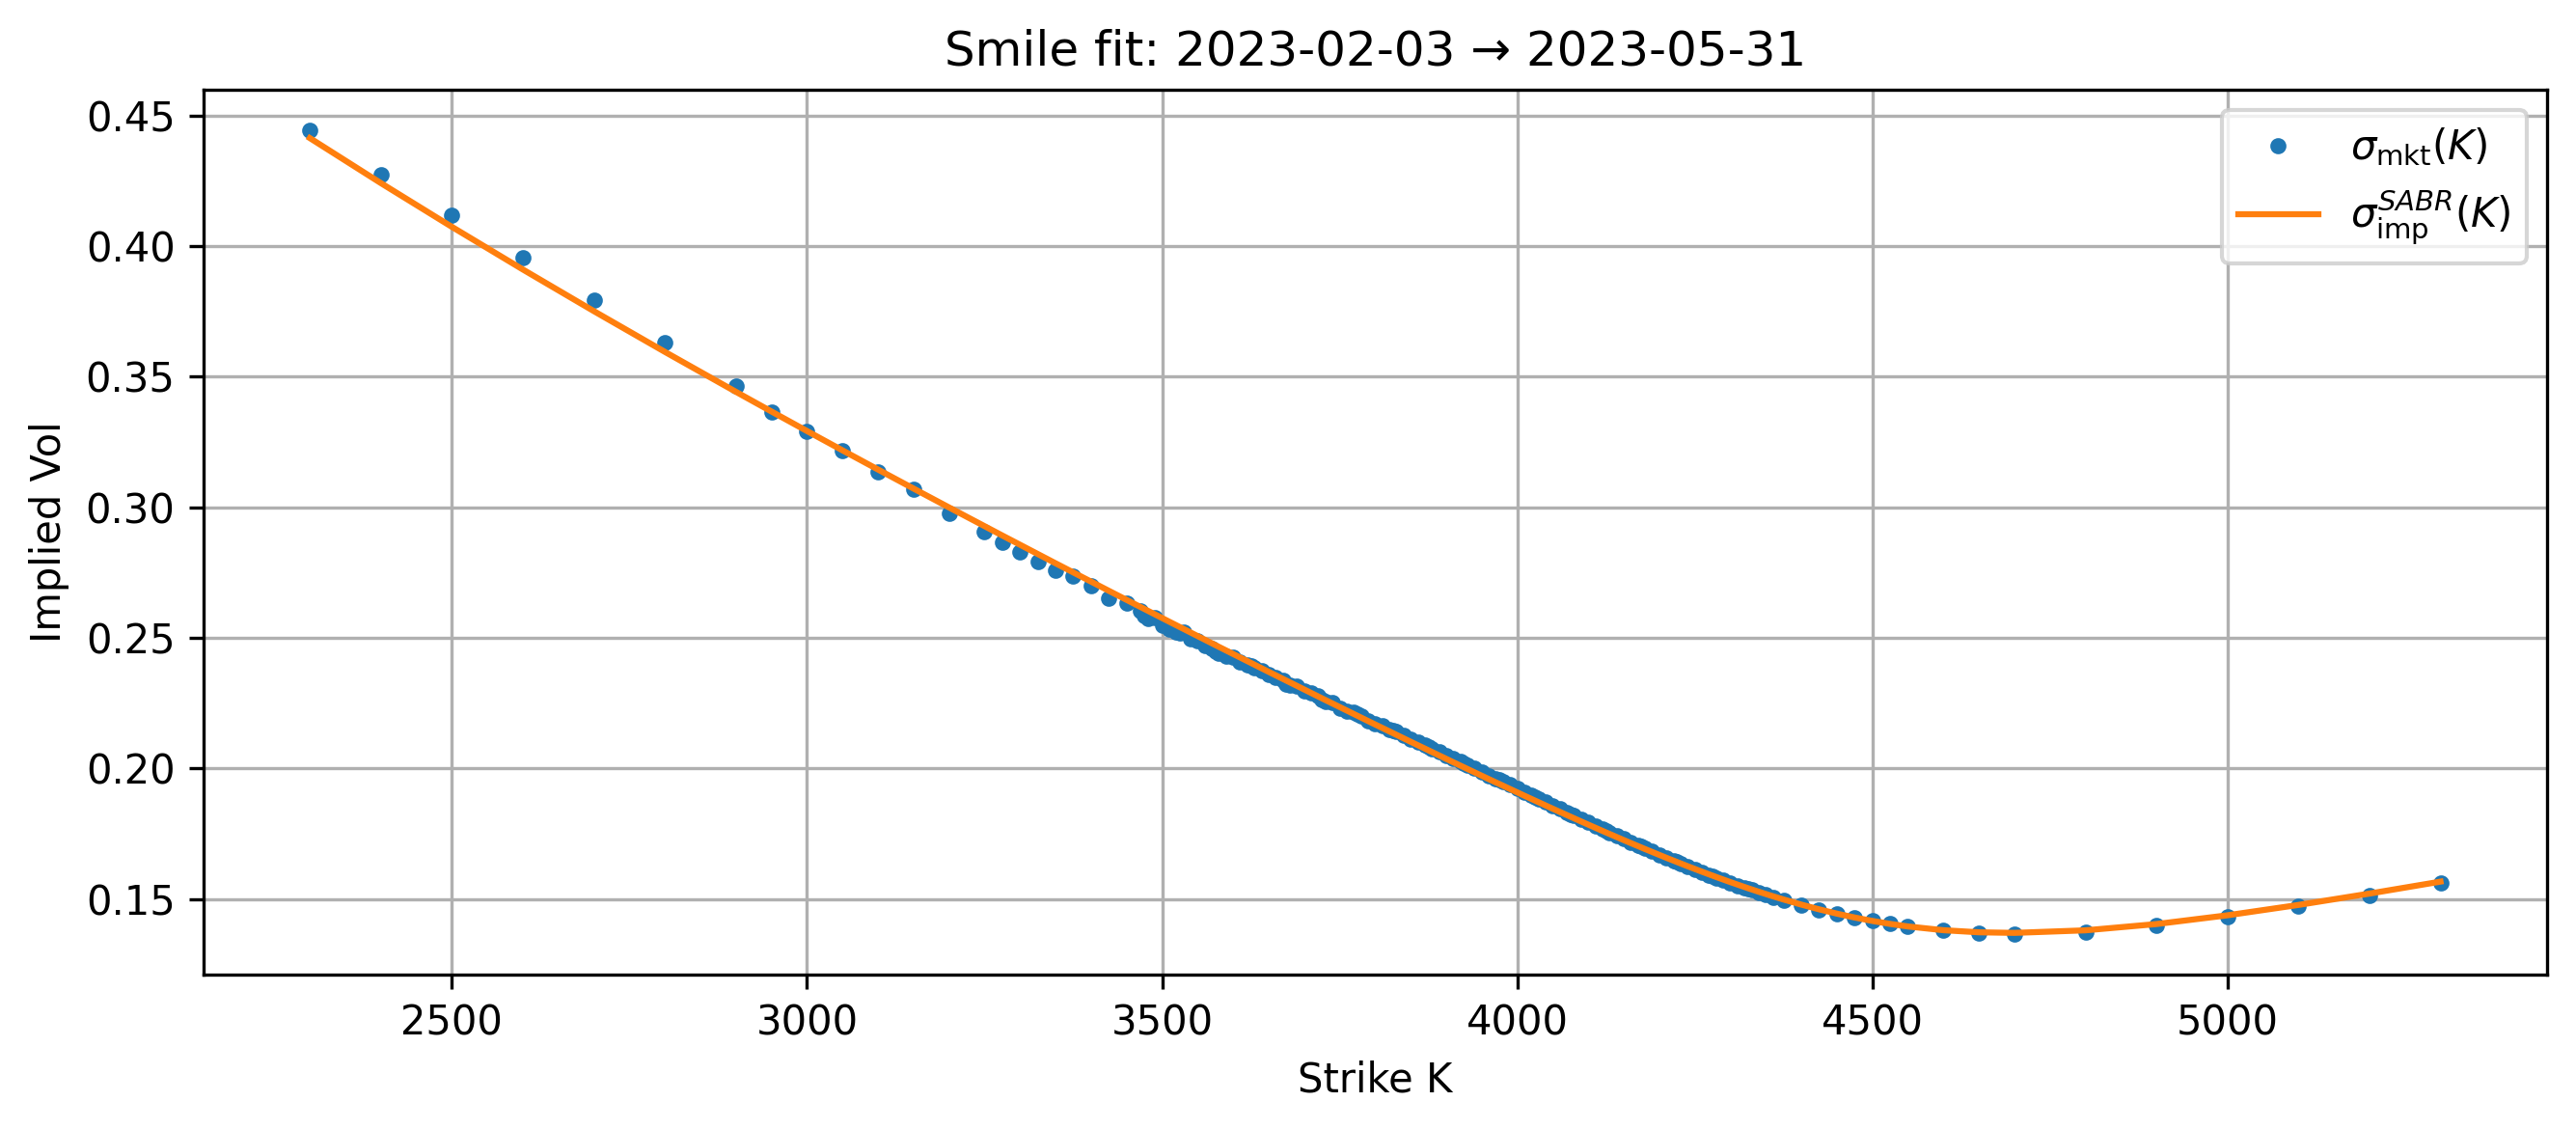

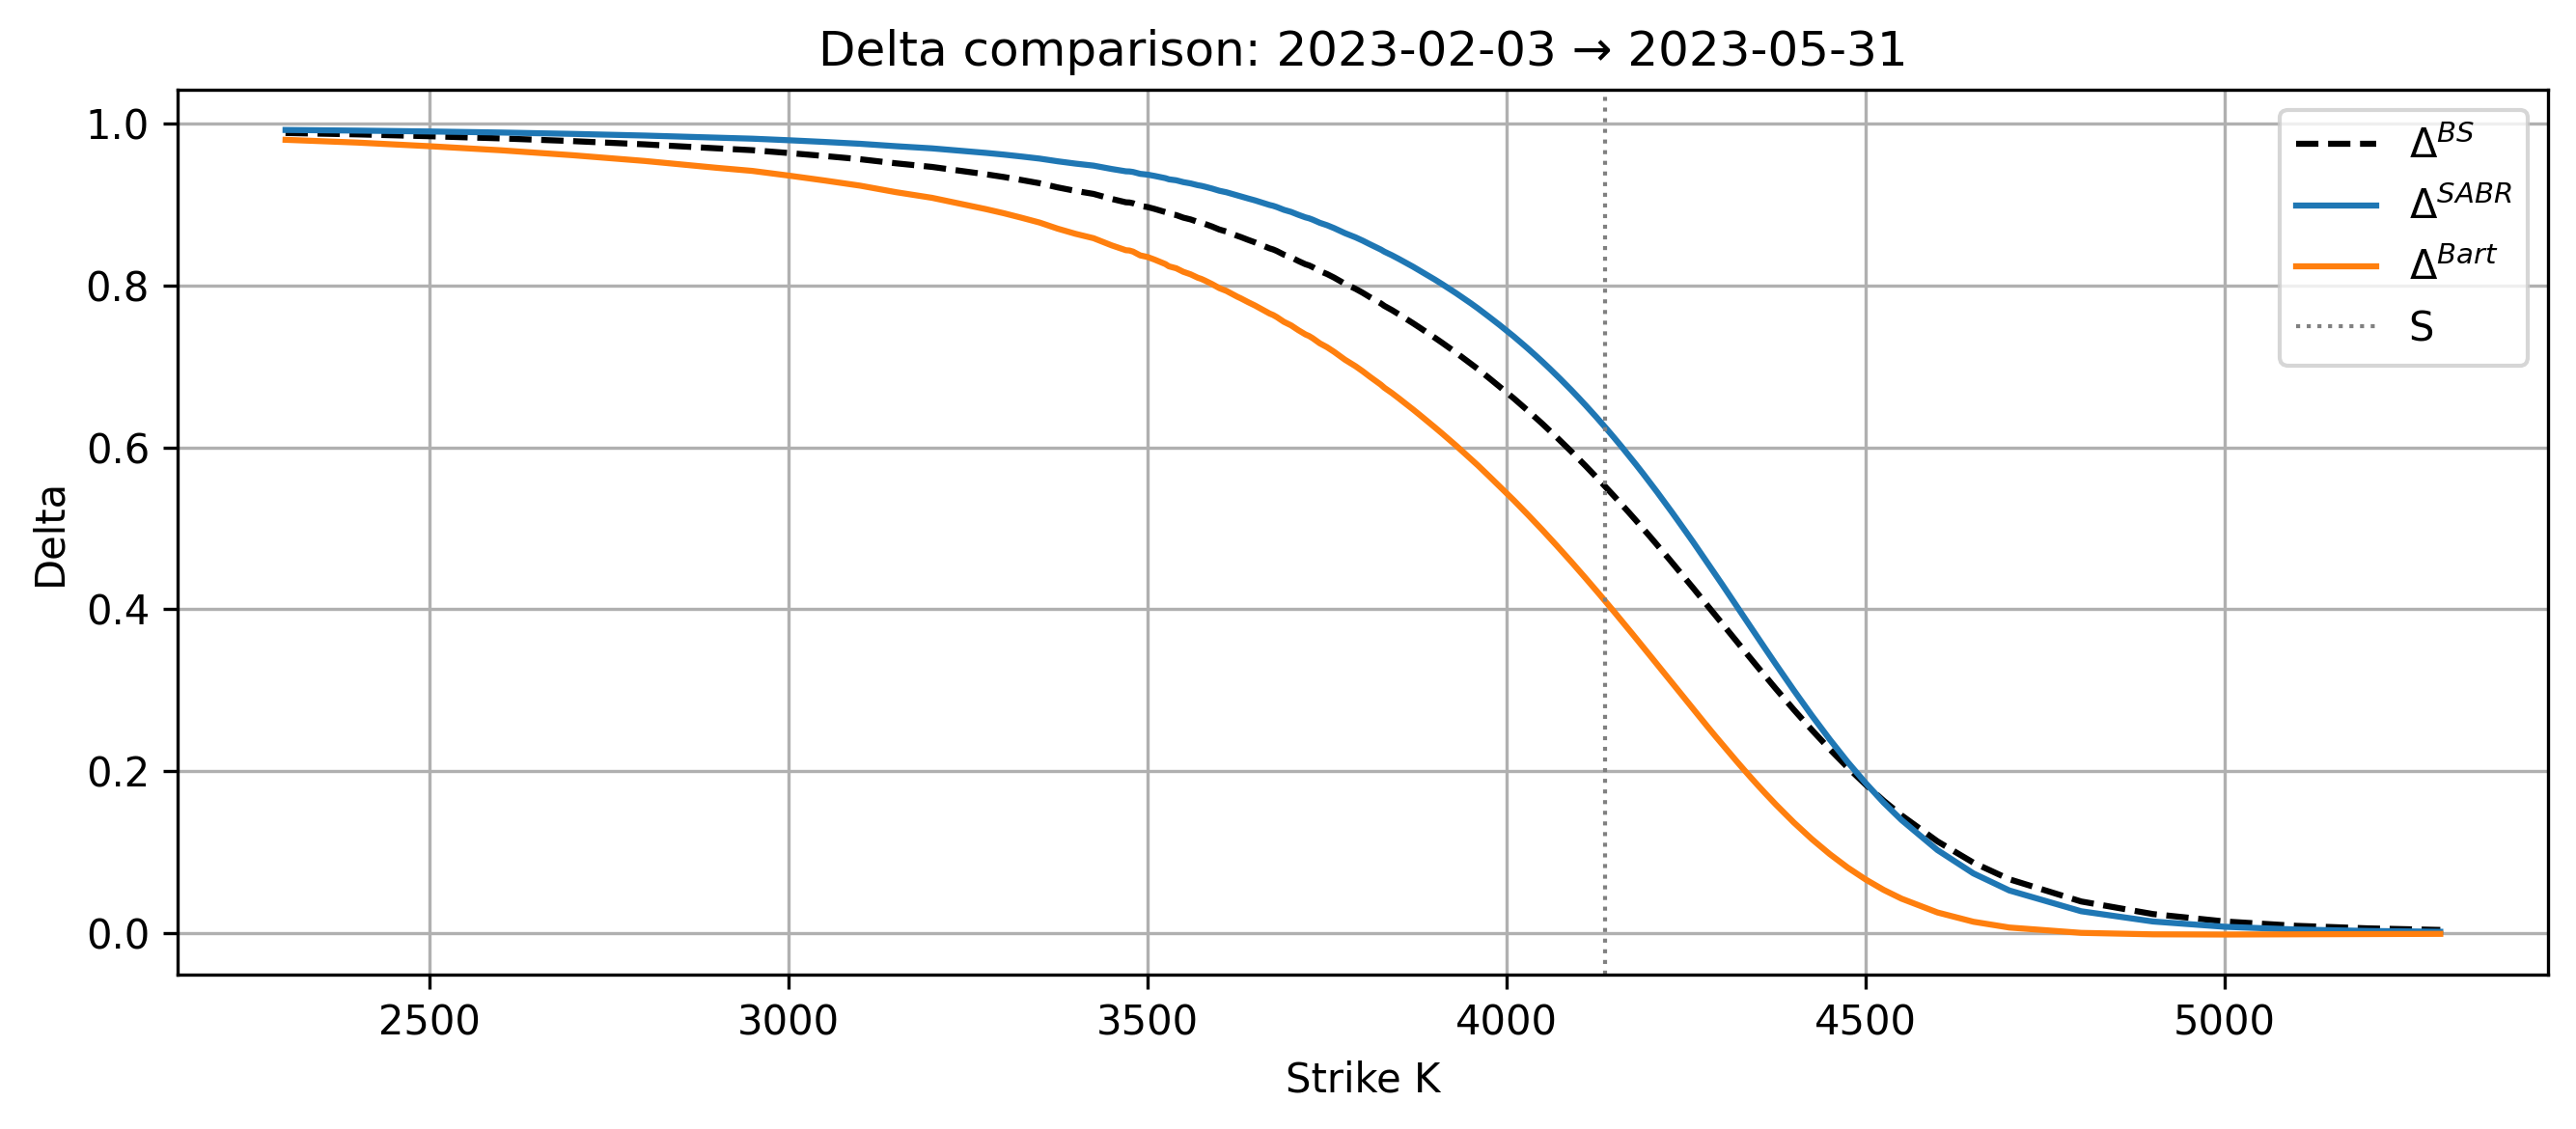

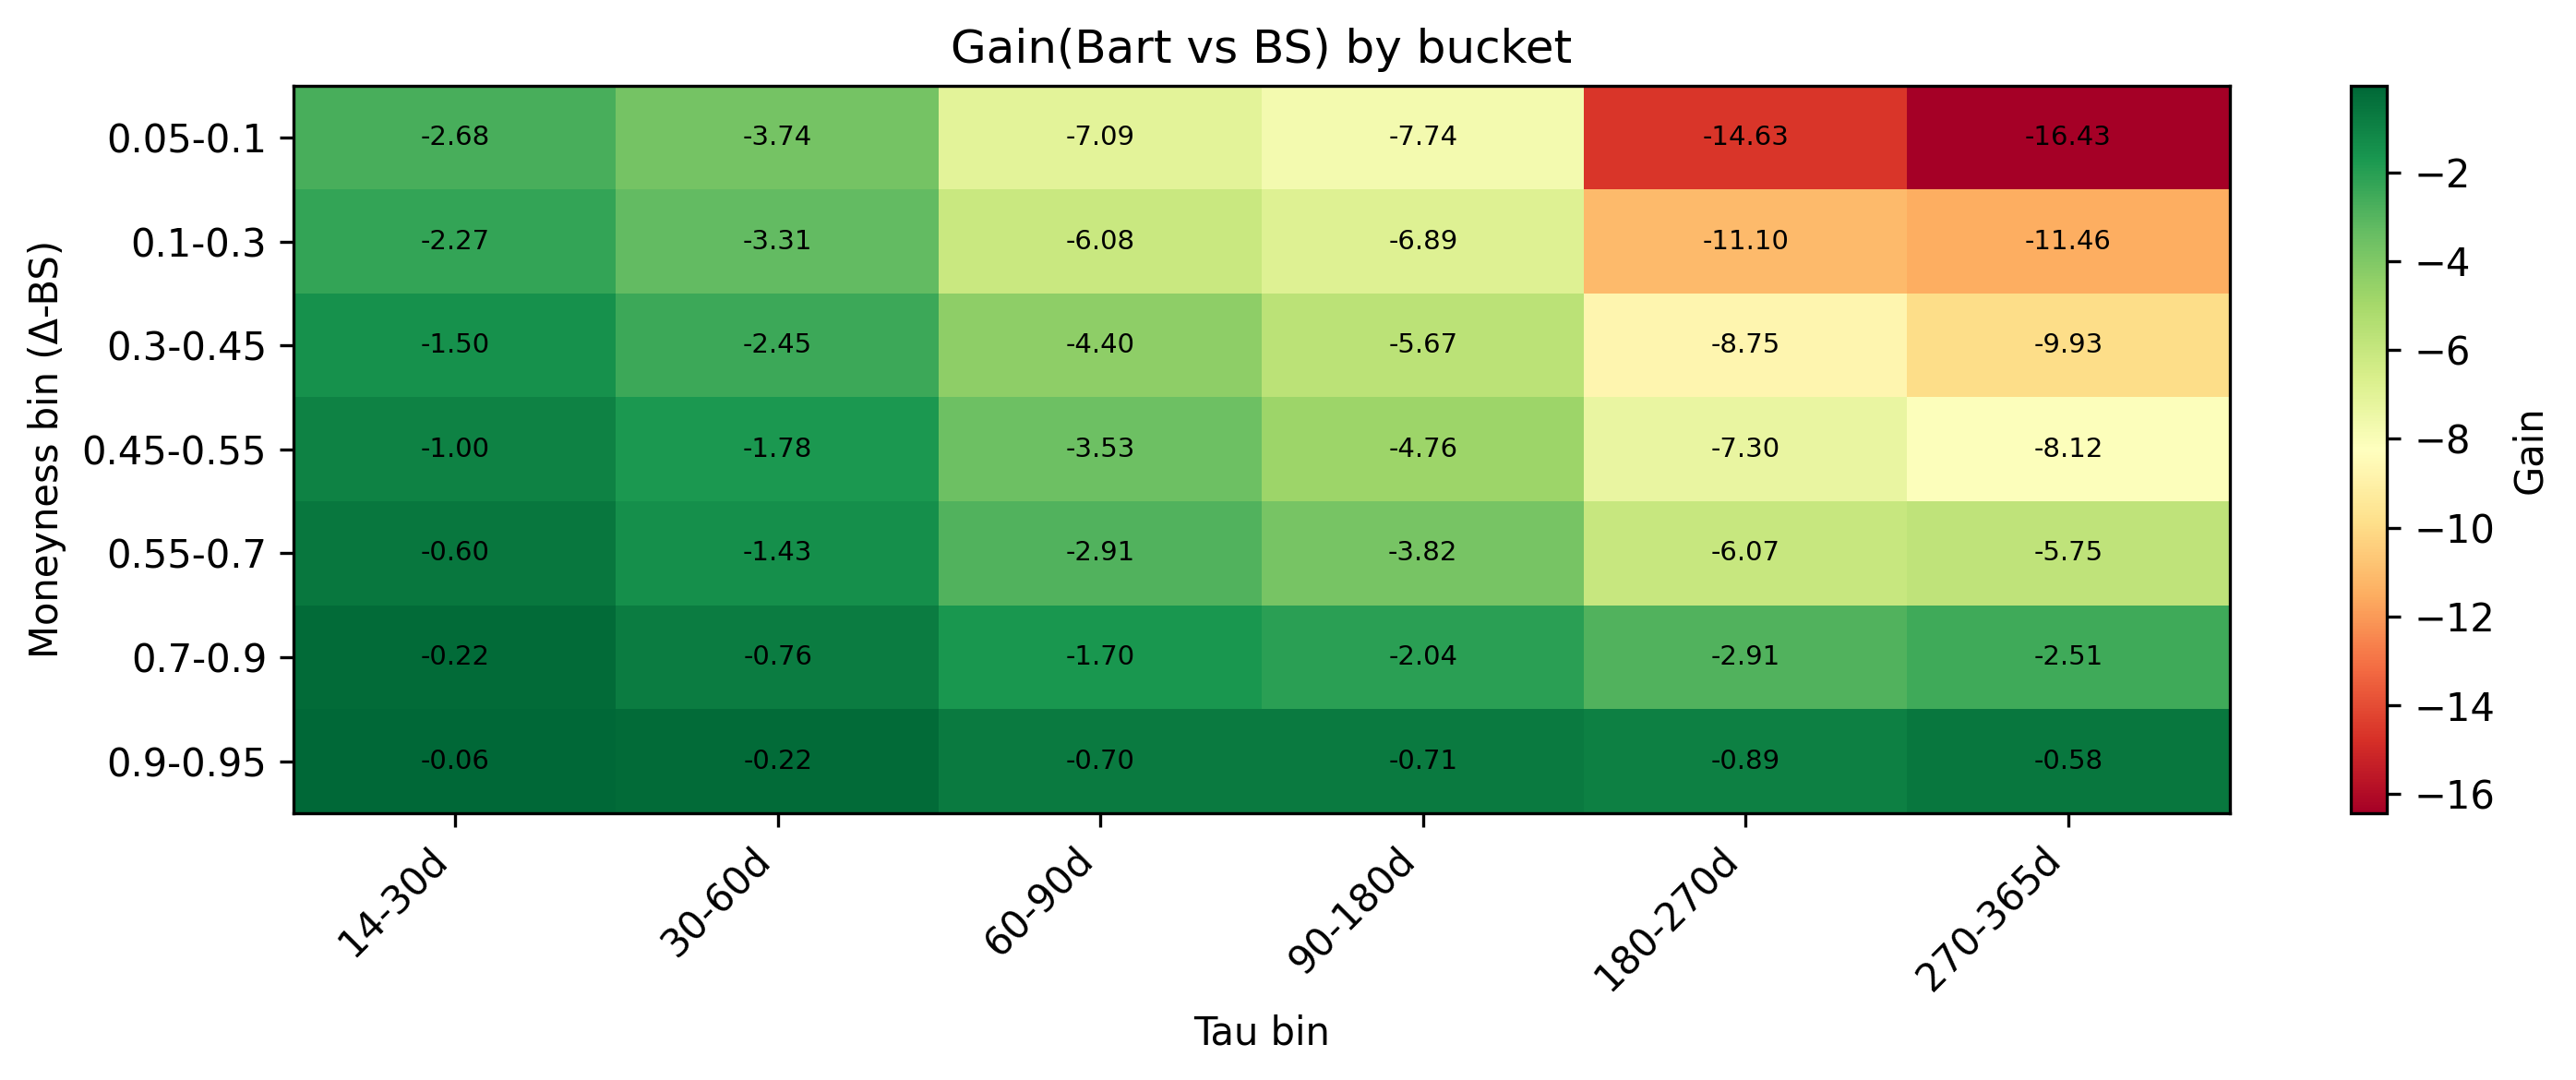

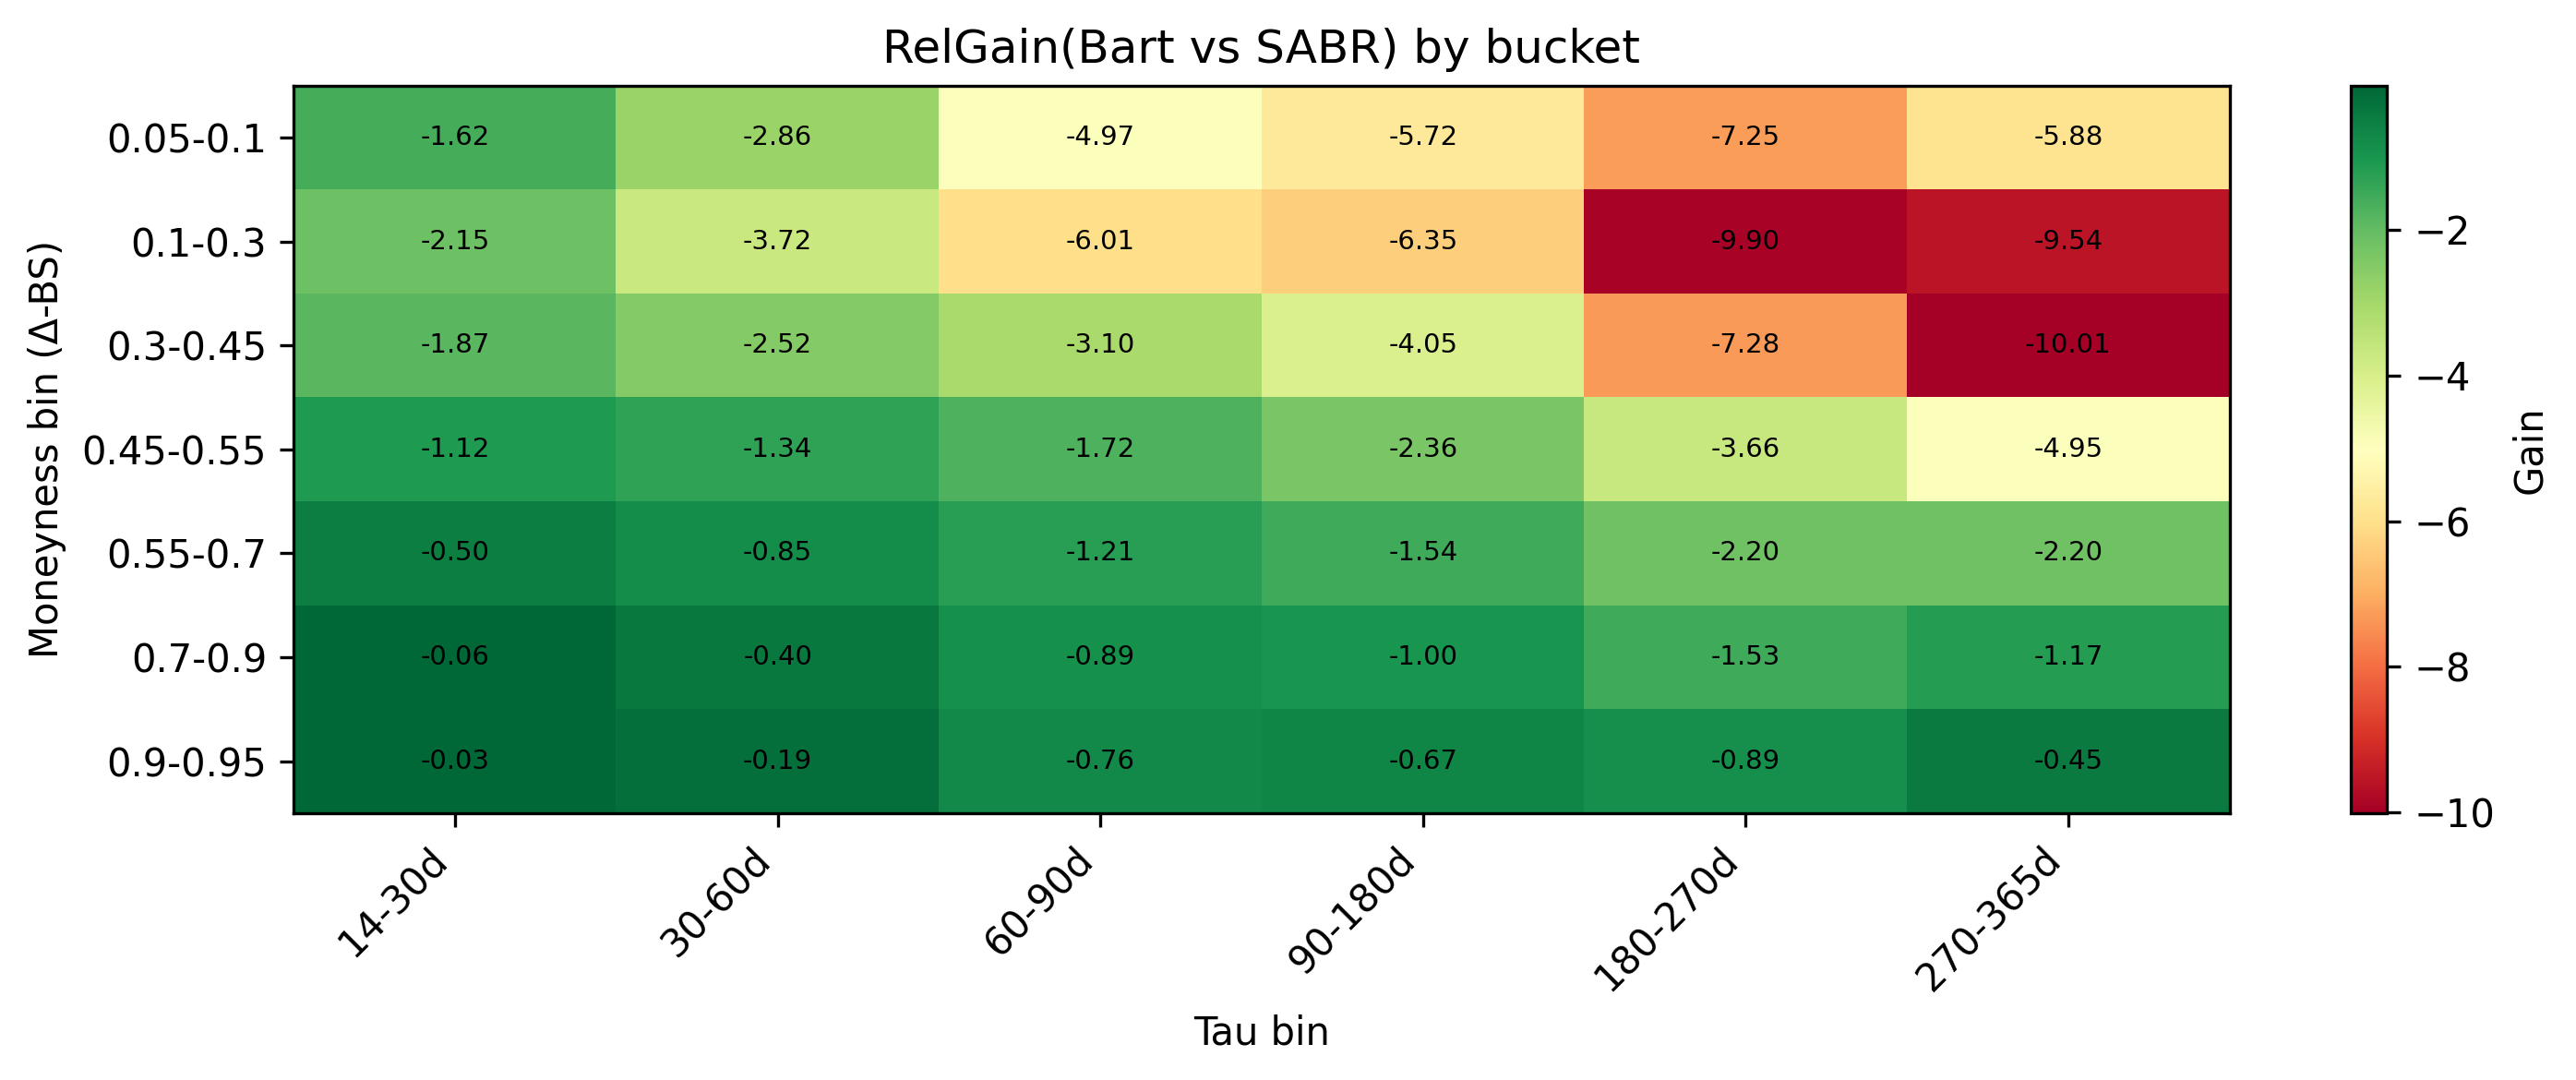

In [354]:
# calc gains

sse_BS   = (df_deltas['eps_BS']**2).sum()
sse_SABR = (df_deltas['eps_SABR']**2).sum()
sse_Bart = (df_deltas['eps_Bartlett']**2).sum()

gain_SABR = 1 - sse_SABR / sse_BS
gain_Bart = 1 - sse_Bart / sse_BS
relgain   = 1 - sse_Bart / sse_SABR

print("Total Gains:")
print(f"  Gain(SABR vs BS):      {gain_SABR:.4f}")
print(f"  Gain(Bart vs BS):      {gain_Bart:.4f}")
print(f"  RelGain(Bart vs SABR): {relgain:.4f}")

# bucketed gains
def bucket_sse(df, eps_col):
    return df.groupby(['moneyness_bin', 'tau_bin'], observed=True)[eps_col].apply(
        lambda x: (x**2).sum()
    )

sse_b_BS   = bucket_sse(df_deltas, 'eps_BS')
sse_b_SABR = bucket_sse(df_deltas, 'eps_SABR')
sse_b_Bart = bucket_sse(df_deltas, 'eps_Bartlett')

gains = pd.DataFrame({
    'Gain_SABR_vs_BS':    1 - sse_b_SABR / sse_b_BS,
    'Gain_Bart_vs_BS':    1 - sse_b_Bart / sse_b_BS,
    'RelGain_Bart_vs_SABR': 1 - sse_b_Bart / sse_b_SABR,
})
print("\nBucketed Gains:")
print(gains.to_string())

# --- Plot 1: smile fit sigma_mkt vs sigma_sabr for a well-calibrated slice ---
row = sabr_params[sabr_params['success'] & (sabr_params['rmse'] < 0.005)].sort_values('rmse').iloc[0]
grp = df_merged[(df_merged['date'] == row['date']) & (df_merged['exdate'] == row['exdate'])]
grp = grp[grp['impl_volatility'] < 1.5].sort_values('strike_price')
F0  = grp['s_t'].iloc[0]
fitted = sabr_vol_vec(F0, grp['strike_price'].values, grp['tau'].iloc[0],
                      row['alpha'], row['rho'], row['nu'])

fig, ax = plt.subplots(figsize=(9, 4), dpi=300)
ax.plot(grp['strike_price'], grp['impl_volatility'], 'o', ms=3, label=r'$\sigma_\mathrm{mkt}(K)$')
ax.plot(grp['strike_price'], fitted, '-', label=r'$\sigma_\mathrm{imp}^{SABR}(K)$')
ax.set_xlabel('Strike K'); ax.set_ylabel('Implied Vol')
ax.set_title(f"Smile fit: {row['date'].date()} → {row['exdate'].date()}")
ax.legend(); ax.grid(); plt.tight_layout(); plt.show()

# --- Plot 2: Delta comparison for same (t, D) ---
S0, tau0 = grp['s_t'].iloc[0], grp['tau'].iloc[0]
K_arr, sig_arr = grp['strike_price'].values, grp['impl_volatility'].values
a0, r0, n0 = row['alpha'], row['rho'], row['nu']

dF  = np.exp(-r*tau0) * stats.norm.cdf(black_d1(S0, K_arr, tau0, sig_arr))
dS  = np.exp(-r*tau0) * S0 * np.sqrt(tau0) * stats.norm.pdf(black_d1(S0, K_arr, tau0, sig_arr))
sc  = np.exp((r-q)*tau0)
d_bs   = bs_delta(S=S0, K=K_arr, tau=tau0, sigma=sig_arr)
d_sabr = sc * (dF + dS * dsigma_dF_vec(S0, K_arr, tau0, a0, r0, n0))
d_bart = sc * (dF + dS * (dsigma_dF_vec(S0, K_arr, tau0, a0, r0, n0)
                           + dsigma_dalpha_vec(S0, K_arr, tau0, a0, r0, n0) * (r0*n0/S0)))

fig, ax = plt.subplots(figsize=(9, 4), dpi=300)
ax.plot(K_arr, d_bs,   'k--', label=r'$\Delta^{BS}$')
ax.plot(K_arr, d_sabr, '-',   label=r'$\Delta^{SABR}$')
ax.plot(K_arr, d_bart, '-',   label=r'$\Delta^{Bart}$')
ax.axvline(S0, color='grey', linestyle=':', linewidth=1, label='S')
ax.set_xlabel('Strike K'); ax.set_ylabel('Delta')
ax.set_title(f"Delta comparison: {row['date'].date()} → {row['exdate'].date()}")
ax.legend(); ax.grid(); plt.tight_layout(); plt.show()

# --- Plot 3 & 4: Heatmaps ---
def pivot_gain(series, title):
    mat = series.unstack('tau_bin')
    fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
    im = ax.imshow(mat.values, aspect='auto', cmap='RdYlGn')
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
    ax.set_xlabel('Tau bin'); ax.set_ylabel('Moneyness bin (Δ-BS)')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Gain')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7)
    plt.tight_layout(); plt.show()

pivot_gain(gains['Gain_Bart_vs_BS'],       'Gain(Bart vs BS) by bucket')
pivot_gain(gains['RelGain_Bart_vs_SABR'],  'RelGain(Bart vs SABR) by bucket')


### 7 - Standardized Outputs

In [355]:
# (a) CalibrationMetrics.csv

calib_out = sabr_params[sabr_params['success']].copy()

# D_days: calendar days to expiry from date
calib_out['D_days'] = (calib_out['exdate'] - calib_out['date']).dt.days

calib_metrics = calib_out[['date', 'D_days', 'tau', 'n_strikes', 'alpha', 'rho', 'nu', 'rmse']].copy()
calib_metrics = calib_metrics.rename(columns={'rmse': 'vol_rmse'})
calib_metrics = calib_metrics.sort_values(['date', 'D_days']).reset_index(drop=True)

calib_metrics.to_csv('CalibrationMetrics.csv', index=False)
print(f"CalibrationMetrics.csv: {len(calib_metrics)} rows")
print(calib_metrics.head())

# (b) HedgingScoreboard.csv

moneyness_bin_cats = df_deltas['moneyness_bin'].cat.categories.tolist()
tau_bin_cats       = df_deltas['tau_bin'].cat.categories.tolist()

def make_scoreboard_row(section, bin1, bin2, subset):
    n = len(subset)
    sse_bs   = (subset['eps_BS']**2).sum()
    sse_sabr = (subset['eps_SABR']**2).sum()
    sse_bart = (subset['eps_Bartlett']**2).sum()
    return {
        'section':              section,
        'bin1':                 bin1,
        'bin2':                 bin2,
        'n_obs':                n,
        'sse_bs':               sse_bs,
        'sse_sabr':             sse_sabr,
        'sse_bartlett':         sse_bart,
        'mse_bs':               sse_bs   / n if n > 0 else np.nan,
        'mse_sabr':             sse_sabr / n if n > 0 else np.nan,
        'mse_bartlett':         sse_bart / n if n > 0 else np.nan,
        'gain_sabr_vs_bs':      1 - sse_sabr / sse_bs   if sse_bs   > 0 else np.nan,
        'gain_bart_vs_bs':      1 - sse_bart / sse_bs   if sse_bs   > 0 else np.nan,
        'relgain_bart_vs_sabr': 1 - sse_bart / sse_sabr if sse_sabr > 0 else np.nan,
    }

rows = []

for i, m_bin in enumerate(moneyness_bin_cats, start=1):
    for j, t_bin in enumerate(tau_bin_cats, start=1):
        subset = df_deltas[
            (df_deltas['moneyness_bin'] == m_bin) &
            (df_deltas['tau_bin']       == t_bin)
        ]
        if len(subset) > 0:
            rows.append(make_scoreboard_row('BUCKET', i, j, subset))

rows.append(make_scoreboard_row('TOTAL', 'TOTAL', 'TOTAL', df_deltas))

scoreboard = pd.DataFrame(rows)
scoreboard.to_csv('HedgingScoreboard.csv', index=False)
print(f"\nHedgingScoreboard.csv: {len(scoreboard)} rows")
print(scoreboard.tail(3).to_string())


CalibrationMetrics.csv: 859 rows
        date  D_days       tau  n_strikes     alpha       rho         nu  \
0 2023-02-02       1  0.002740         55  0.207655 -0.140290  17.870875   
1 2023-02-02       4  0.010959         34  0.145050  0.229697   6.866513   
2 2023-02-02       5  0.013699         40  0.154201  0.248532   5.450789   
3 2023-02-02       6  0.016438         44  0.162907  0.286358   3.945259   
4 2023-02-02       7  0.019178         50  0.161223  0.211051   4.107846   

   vol_rmse  
0  0.067020  
1  0.025606  
2  0.024383  
3  0.016564  
4  0.018965  

HedgingScoreboard.csv: 43 rows
   section   bin1   bin2  n_obs        sse_bs      sse_sabr  sse_bartlett     mse_bs   mse_sabr  mse_bartlett  gain_sabr_vs_bs  gain_bart_vs_bs  relgain_bart_vs_sabr
40  BUCKET      7      5   1258  1.235476e+04  1.238066e+04  2.335554e+04   9.820950   9.841542     18.565613        -0.002097        -0.890409             -0.886454
41  BUCKET      7      6   1171  1.259223e+04  1.373996e+04  1